# Analyse Exploratoire — Bénin Insights Challenge
## Groupe 16 · iSHEERO × DataCamp Donates · 2025

**Objectif :** Explorer les données GDELT du Bénin (2025) pour
identifier les patterns clés, préparer les features ML et produire
des insights actionnables pour journalistes, chercheurs et décideurs.

**Source :** `data/processed/benin_2025_clean.csv`
**Modèles ML :** Random Forest (classification) + Isolation Forest (anomalies)
**Auteurs :** Groupe 16

## 0. Chargement des données

On charge le dataset gold produit par le pipeline officiel.
Une inspection rapide confirme l'intégrité des données
avant de lancer l'analyse.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Style global
plt.rcParams.update({
    'figure.dpi': 150,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
    'font.family': 'sans-serif'
})

# Chargement
df = pd.read_csv('../../data/processed/benin_2025_clean.csv',
                 parse_dates=['SQLDATE'])

# Inspection rapide
print(f"=== Dataset chargé ===")
print(f"Lignes     : {len(df):,}")
print(f"Colonnes   : {len(df.columns)}")
print(f"Période    : {df['SQLDATE'].min().date()} → {df['SQLDATE'].max().date()}")
print(f"\n=== Aperçu ===")
display(df.head())
print(f"\n=== Types ===")
print(df.dtypes)
print(f"\n=== Valeurs manquantes ===")
missing = df.isnull().sum()
print(missing[missing > 0].to_string())

=== Dataset chargé ===
Lignes     : 23,461
Colonnes   : 26
Période    : 2025-01-01 → 2025-12-31

=== Aperçu ===


,SQLDATE,EventCode,EventBaseCode,EventRootCode,QuadClass,Actor1Name,Actor1CountryCode,Actor1Type1Code,Actor2Name,Actor2CountryCode,...,NumArticles,AvgTone,SOURCEURL,mois,zone_geo,type_quadclass,is_violent,impact_pondere,source_domain,communaute_linguistique
0,2025-12-31,1712,171,17,4,OPERATIVE,NaN,SPY,Non identifié,NaN,...,10,-9.577465,https://dailypost.ng/2025/12/31/nscdc-arrests-...,2025-12,Non localisé,Conflit matériel,True,-22.060637,dailypost.ng,Anglophone / Commonwealth
1,2025-02-09,16,16,1,1,CONGRESS,NaN,LEG,DEMOCRATIC PARTY,NaN,...,10,-5.177994,https://thesun.ng/apc-dismisses-pdps-claims-on...,2025-02,Non localisé,Coopération verbale,False,-4.795791,thesun.ng,Anglophone / Commonwealth
2,2025-02-09,1712,171,17,4,BENIN,BEN,Non identifié,BENIN CITY,NGA,...,4,-5.309735,https://dailypost.ng/2025/02/09/police-rescue-...,2025-02,Non localisé,Conflit matériel,True,-14.806829,dailypost.ng,Anglophone / Commonwealth
3,2025-03-04,22,22,2,1,PRISONER,NaN,OPP,Non identifié,NaN,...,10,-2.621723,https://lanouvelletribune.info/2026/03/benin-d...,2025-03,Non localisé,Coopération verbale,False,7.673265,lanouvelletribune.info,Francophonie
4,2025-01-01,16,16,1,1,GOVERNOR,NaN,GOV,Non identifié,NaN,...,3,-12.206573,https://punchng.com/pdp-seeks-igs-intervention...,2025-01,Non localisé,Coopération verbale,False,-2.772589,punchng.com,Anglophone / Commonwealth



=== Types ===
SQLDATE                    datetime64[ns]
EventCode                           int64
EventBaseCode                       int64
EventRootCode                       int64
QuadClass                           int64
Actor1Name                         object
Actor1CountryCode                  object
Actor1Type1Code                    object
Actor2Name                         object
Actor2CountryCode                  object
Actor2Type1Code                    object
ActionGeo_FullName                 object
ActionGeo_Lat                     float64
ActionGeo_Long                    float64
GoldsteinScale                    float64
NumMentions                         int64
NumArticles                         int64
AvgTone                           float64
SOURCEURL                          object
mois                               object
zone_geo                           object
type_quadclass                     object
is_violent                           bool
impact_pondere     

### Constat
Le dataset gold est chargé avec succès : **23 461 lignes et 26 colonnes**
couvrant du **2025-01-01 au 2025-12-31**.

Les 26 colonnes se répartissent en :
- 19 colonnes originales GDELT (données brutes)
- 7 colonnes dérivées : `mois`, `zone_geo`, `type_quadclass`,
  `is_violent`, `impact_pondere`, `source_domain`,
  `communaute_linguistique`

Seules `Actor1CountryCode` (49.2%) et `Actor2CountryCode` (58.3%)
conservent des valeurs manquantes — conformément à la stratégie
du pipeline (manquants informatifs conservés intentionnellement).

Les types sont cohérents : `SQLDATE` en datetime, `is_violent`
en booléen, les métriques clés en float64.
Le dataset est prêt pour l'analyse exploratoire.

## 1. Portrait des événements : qui fait quoi au Bénin ?

### Objectif
Comprendre la nature des événements impliquant le Bénin en 2025 —
quels types dominent, quelle proportion est violente, et quels
acteurs sont associés à la violence.

Cette visualisation justifie `is_violent` comme variable cible
du modèle Random Forest : la violence n'est pas aléatoire,
elle est concentrée sur certains types d'événements et certains
acteurs spécifiques.

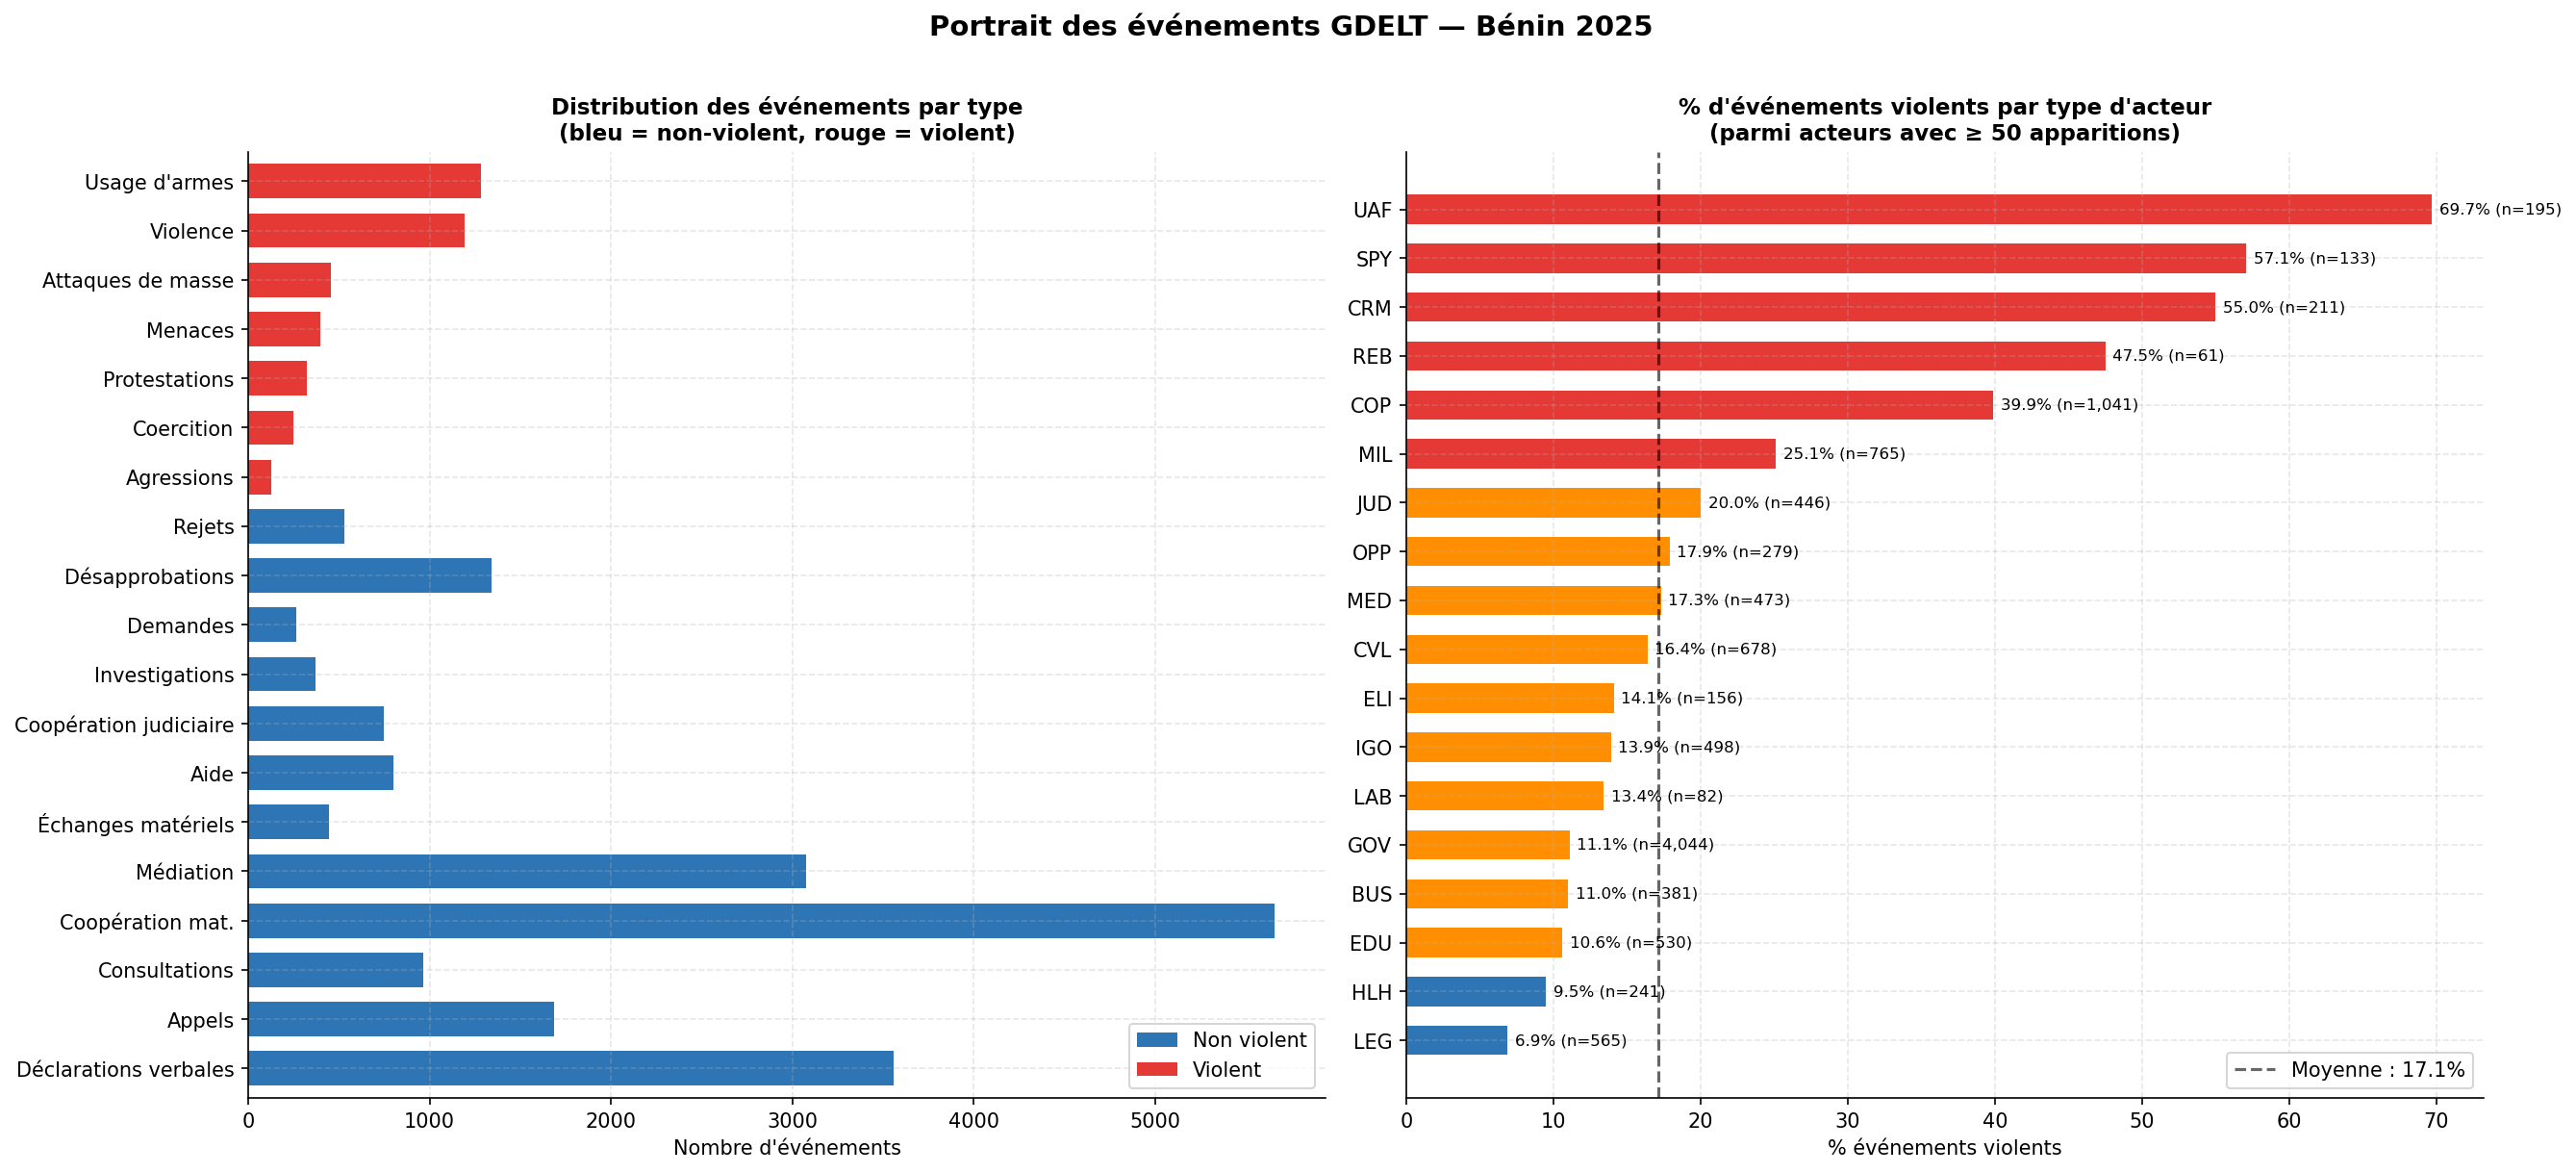

=== Statistiques clés ===
Total événements     : 23,461
Événements violents  : 4,023 (17.1%)

Top 5 types les plus violents :
Usage d'armes        1285
Violence             1194
Attaques de masse     454
Menaces               395
Protestations         323


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# ── Graphique gauche : Distribution EventRootCode colorée par is_violent ──
cameo_labels = {
    1: "Déclarations verbales", 2: "Appels", 3: "Consultations",
    4: "Coopération mat.", 5: "Médiation", 6: "Échanges matériels",
    7: "Aide", 8: "Coopération judiciaire", 9: "Investigations",
    10: "Demandes", 11: "Désapprobations", 12: "Rejets",
    13: "Menaces", 14: "Protestations", 15: "Coercition",
    16: "Agressions", 17: "Violence", 18: "Attaques de masse",
    19: "Usage d'armes", 20: "Guerre conventionnelle"
}

# Compter violent vs non-violent par EventRootCode
counts = df.groupby(['EventRootCode', 'is_violent']).size().unstack(fill_value=0)
counts.index = [cameo_labels.get(i, str(i)) for i in counts.index]
counts = counts.sort_values(True, ascending=True)

counts.plot(kind='barh', stacked=True, ax=axes[0],
            color=['#2E75B6', '#E53935'], width=0.7)
axes[0].set_title("Distribution des événements par type\n(bleu = non-violent, rouge = violent)",
                   fontweight='bold', fontsize=11)
axes[0].set_xlabel("Nombre d'événements")
axes[0].set_ylabel("")
axes[0].legend(['Non violent', 'Violent'], loc='lower right')

# ── Graphique droite : % violence par Actor1Type1Code ──
actor_violence = df[df['Actor1Type1Code'] != 'Non identifié'].groupby(
    'Actor1Type1Code').agg(
    total=('is_violent', 'count'),
    violent=('is_violent', 'sum')
).reset_index()
actor_violence['pct_violent'] = (actor_violence['violent'] /
                                  actor_violence['total'] * 100).round(1)
actor_violence = actor_violence[actor_violence['total'] >= 50]
actor_violence = actor_violence.sort_values('pct_violent', ascending=True)

colors = ['#E53935' if p > 20 else '#FF8F00' if p > 10
          else '#2E75B6' for p in actor_violence['pct_violent']]
bars = axes[1].barh(actor_violence['Actor1Type1Code'],
                    actor_violence['pct_violent'],
                    color=colors, height=0.6)
axes[1].axvline(df['is_violent'].mean() * 100, color='black',
                linestyle='--', alpha=0.6,
                label=f"Moyenne : {df['is_violent'].mean()*100:.1f}%")
for bar, (_, row) in zip(bars, actor_violence.iterrows()):
    axes[1].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                f"{row['pct_violent']}% (n={row['total']:,})",
                va='center', fontsize=8)
axes[1].set_title("% d'événements violents par type d'acteur\n(parmi acteurs avec ≥ 50 apparitions)",
                   fontweight='bold', fontsize=11)
axes[1].set_xlabel("% événements violents")
axes[1].legend()

plt.suptitle("Portrait des événements GDELT — Bénin 2025",
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../../reports/viz1_portrait_evenements.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Stats complémentaires
print("=== Statistiques clés ===")
print(f"Total événements     : {len(df):,}")
print(f"Événements violents  : {df['is_violent'].sum():,} ({df['is_violent'].mean()*100:.1f}%)")
print(f"\nTop 5 types les plus violents :")
top_violent = df[df['is_violent']].groupby('EventRootCode').size()
top_violent.index = [cameo_labels.get(i, str(i)) for i in top_violent.index]
print(top_violent.sort_values(ascending=False).head(5).to_string())

### Légende des codes acteurs (Actor1Type1Code)

| Code | Libellé | Description |
|------|---------|-------------|
| UAF | Forces armées non identifiées | Groupes armés sans affiliation claire |
| SPY | Services de renseignement | Agences d'espionnage, services secrets |
| CRM | Criminalité | Acteurs criminels, gangs |
| REB | Rebelles | Groupes insurgés, mouvements armés |
| COP | Forces de l'ordre | Police, gendarmerie |
| MIL | Militaire | Forces armées nationales |
| JUD | Justice | Tribunaux, système judiciaire |
| OPP | Opposition politique | Partis d'opposition, militants |
| MED | Médias | Journalistes, organes de presse |
| CVL | Civils | Population civile générale |
| ELI | Élites | Élites économiques et sociales |
| IGO | Organisations internationales | ONU, UA, CEDEAO, etc. |
| LAB | Syndicats / Travail | Organisations syndicales |
| GOV | Gouvernement | Acteurs gouvernementaux officiels |
| BUS | Entreprises | Acteurs du secteur privé |
| EDU | Éducation | Institutions académiques |
| HLH | Santé | Acteurs du secteur sanitaire |
| LEG | Législatif | Parlementaires, assemblées |

### Constat

**Distribution des types d'événements :**
Les événements coopératifs dominent largement la couverture médiatique
du Bénin en 2025. La Coopération matérielle, les Déclarations verbales
et la Médiation représentent à elles seules plus de 50% des événements.
Les événements violents (Usage d'armes, Violence, Attaques de masse,
Menaces, Protestations, Coercition, Agressions) représentent **17.1%**
du total soit **4 023 événements** — une présence significative
qui justifie pleinement la construction d'un modèle de classification.

**Top 5 des types violents :**
- Usage d'armes : 1 285 événements
- Violence directe : 1 194 événements
- Attaques de masse : 454 événements
- Menaces : 395 événements
- Protestations : 323 événements

Ces 5 types représentent **91.8%** de tous les événements violents.

**% de violence par type d'acteur — insights majeurs :**

Les acteurs les plus violents confirment la réalité sécuritaire du Bénin :
- **UAF (Forces armées non identifiées) : 69.7%** — 7 événements
  sur 10 impliquant des groupes armés non identifiés sont violents.
  C'est le signal le plus fort de la présence jihadiste dans le nord.
- **SPY (Renseignement) : 57.1%** et **CRM (Criminalité) : 55.0%**
  — présences attendues dans un contexte sécuritaire dégradé.
- **REB (Rebelles) : 47.5%** — confirme l'activité de groupes
  insurgés dans les zones frontalières.
- **COP (Forces de l'ordre) : 39.9% sur 1 041 événements** —
  chiffre élevé qui reflète les opérations sécuritaires de riposte
  aux attaques terroristes, pas nécessairement de la violence
  illégitime.

**Acteurs institutionnels :**
- **GOV (Gouvernement) : 11.1% sur 4 044 événements** — taux
  modéré, cohérent avec un gouvernement actif diplomatiquement
  mais confronté à des défis sécuritaires.
- **LEG (Législatif) : 6.9%** et **HLH (Santé) : 9.5%** —
  taux les plus bas, attendu pour des acteurs institutionnels
  civils.

**Implication pour le modèle Random Forest :**
`Actor1Type1Code` sera une feature hautement discriminante —
l'écart entre UAF (69.7%) et LEG (6.9%) est de 63 points.
Le modèle pourra s'appuyer fortement sur le type d'acteur
pour prédire la violence d'un événement.

## 2. La timeline du Bénin en 2025

### Objectif
Analyser l'évolution mensuelle de trois indicateurs simultanément :
volume médiatique, stabilité (Goldstein) et intensité conflictuelle
(% violent). Cette triple lecture permet d'identifier les périodes
anormales que le modèle Isolation Forest devra détecter automatiquement.

Un mois "anormal" se caractérise par une combinaison de :
volume inhabituel + Goldstein bas + % violent élevé.

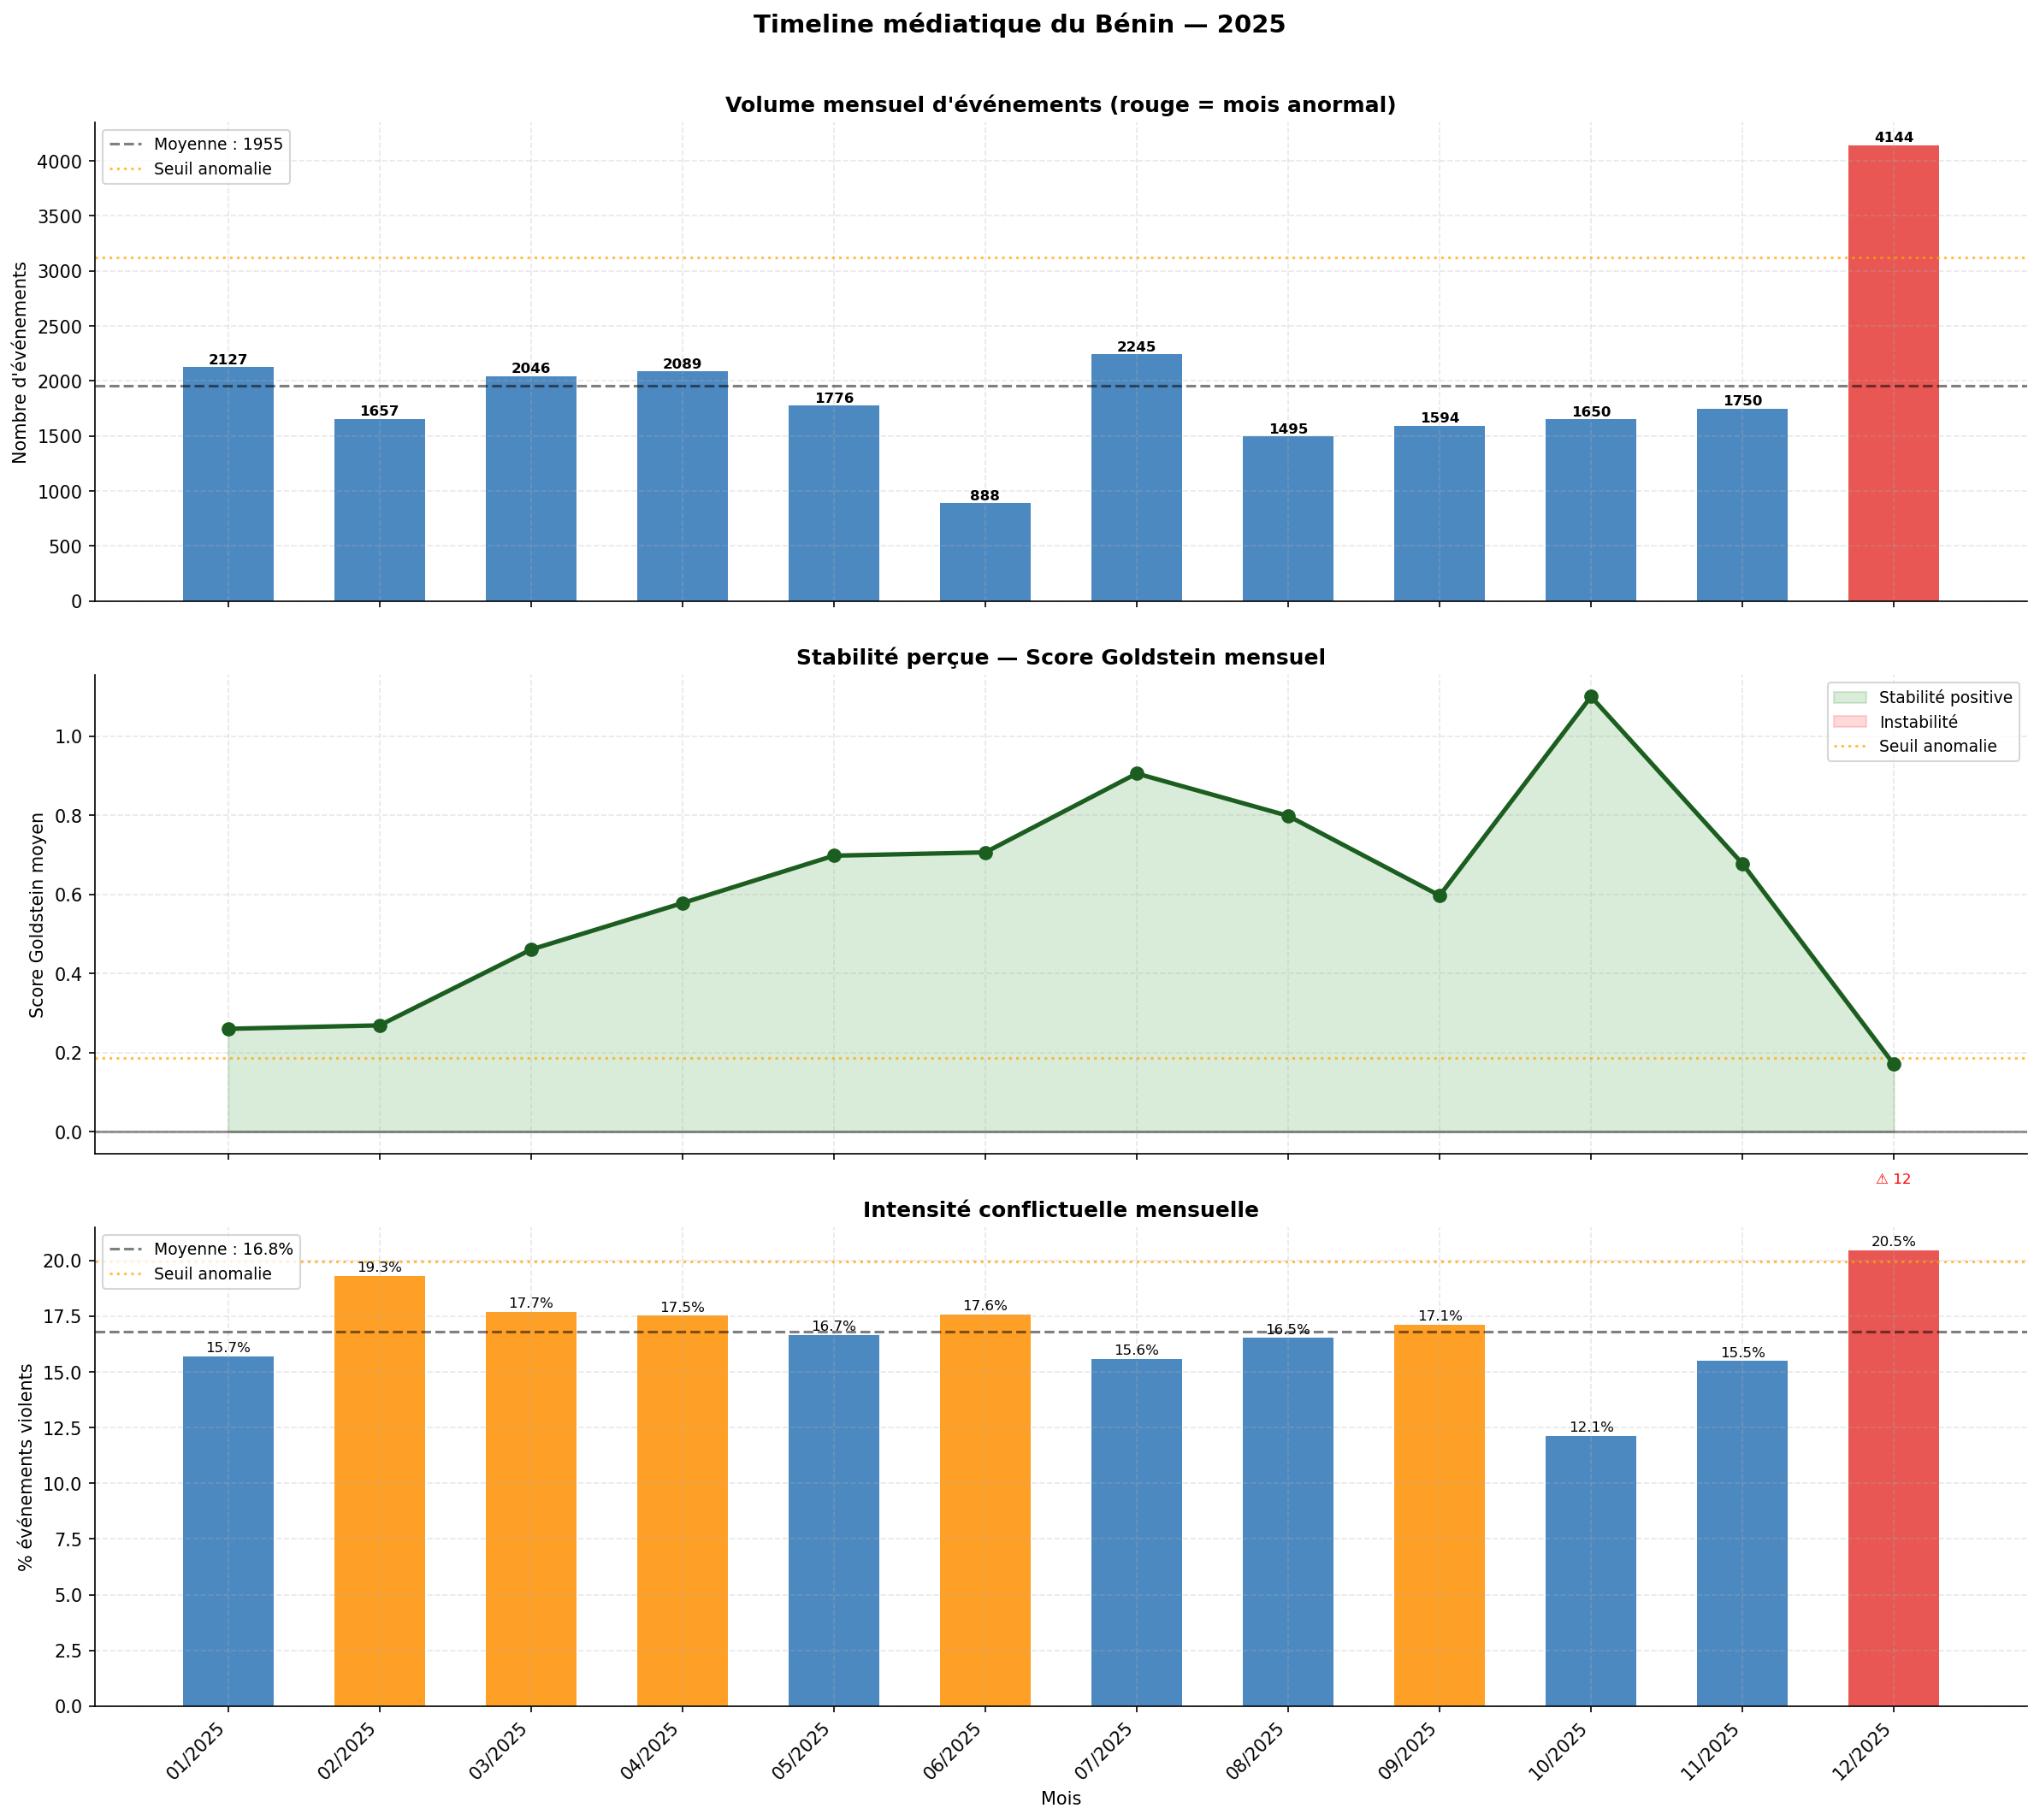

=== Mois identifiés comme anormaux ===
   mois  nb_evenements  goldstein_moyen  pct_violent
2025-12           4144         0.170294     20.46332

=== Résumé annuel ===
Mois le plus actif    : 2025-12 (4,144 événements)
Mois le plus stable   : 2025-10 (Goldstein : 1.10)
Mois le plus violent  : 2025-12 (20.5%)


In [9]:
# Agrégation mensuelle
monthly = df.groupby('mois').agg(
    nb_evenements=('SQLDATE', 'count'),
    goldstein_moyen=('GoldsteinScale', 'mean'),
    ton_moyen=('AvgTone', 'mean'),
    pct_violent=('is_violent', 'mean'),
    impact_moyen=('impact_pondere', 'mean'),
    nb_articles=('NumArticles', 'sum')
).reset_index()
monthly['pct_violent'] = monthly['pct_violent'] * 100

# Seuils d'anomalie (moyenne ± 1.5 std)
moy_vol = monthly['nb_evenements'].mean()
std_vol = monthly['nb_evenements'].std()
moy_gold = monthly['goldstein_moyen'].mean()
std_gold = monthly['goldstein_moyen'].std()
moy_viol = monthly['pct_violent'].mean()
std_viol = monthly['pct_violent'].std()

# Flag anomalie simple
monthly['is_anomalie'] = (
    (monthly['nb_evenements'] > moy_vol + 1.5 * std_vol) |
    (monthly['goldstein_moyen'] < moy_gold - 1.5 * std_gold) |
    (monthly['pct_violent'] > moy_viol + 1.5 * std_viol)
)

fig, axes = plt.subplots(3, 1, figsize=(16, 14), sharex=True)
mois_labels = [m[-2:] + '/' + m[:4] for m in monthly['mois']]
x = range(len(monthly))

# ── Graphique 1 : Volume mensuel ──────────────────────────────
colors_vol = ['#E53935' if a else '#2E75B6'
              for a in monthly['is_anomalie']]
bars = axes[0].bar(x, monthly['nb_evenements'],
                   color=colors_vol, alpha=0.85, width=0.6)
axes[0].axhline(moy_vol, color='black', linestyle='--',
                alpha=0.5, label=f'Moyenne : {moy_vol:.0f}')
axes[0].axhline(moy_vol + 1.5*std_vol, color='orange',
                linestyle=':', alpha=0.7, label='Seuil anomalie')
for bar, val in zip(bars, monthly['nb_evenements']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                str(val), ha='center', fontsize=8, fontweight='bold')
axes[0].set_ylabel("Nombre d'événements")
axes[0].set_title("Volume mensuel d'événements (rouge = mois anormal)",
                   fontweight='bold')
axes[0].legend(fontsize=9)

# ── Graphique 2 : Score Goldstein ─────────────────────────────
axes[1].plot(x, monthly['goldstein_moyen'], color='#1B5E20',
             linewidth=2.5, marker='o', markersize=7, zorder=3)
axes[1].fill_between(x, monthly['goldstein_moyen'], 0,
                     where=monthly['goldstein_moyen'] >= 0,
                     alpha=0.15, color='green', label='Stabilité positive')
axes[1].fill_between(x, monthly['goldstein_moyen'], 0,
                     where=monthly['goldstein_moyen'] < 0,
                     alpha=0.15, color='red', label='Instabilité')
axes[1].axhline(0, color='black', linestyle='-', alpha=0.4)
axes[1].axhline(moy_gold - 1.5*std_gold, color='orange',
                linestyle=':', alpha=0.7, label='Seuil anomalie')

# Annoter les mois anormaux
for i, row in monthly.iterrows():
    if row['is_anomalie']:
        axes[1].annotate(f"⚠ {row['mois'][5:]}",
                        xy=(i, row['goldstein_moyen']),
                        xytext=(i, row['goldstein_moyen'] - 0.3),
                        fontsize=8, color='red', ha='center')

axes[1].set_ylabel("Score Goldstein moyen")
axes[1].set_title("Stabilité perçue — Score Goldstein mensuel",
                   fontweight='bold')
axes[1].legend(fontsize=9)

# ── Graphique 3 : % Violence ──────────────────────────────────
colors_viol = ['#E53935' if v > moy_viol + 1.5*std_viol
               else '#FF8F00' if v > moy_viol
               else '#2E75B6' for v in monthly['pct_violent']]
bars3 = axes[2].bar(x, monthly['pct_violent'],
                    color=colors_viol, alpha=0.85, width=0.6)
axes[2].axhline(moy_viol, color='black', linestyle='--',
                alpha=0.5, label=f'Moyenne : {moy_viol:.1f}%')
axes[2].axhline(moy_viol + 1.5*std_viol, color='orange',
                linestyle=':', alpha=0.7, label='Seuil anomalie')
for bar, val in zip(bars3, monthly['pct_violent']):
    axes[2].text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.2,
                f'{val:.1f}%', ha='center', fontsize=8)
axes[2].set_ylabel("% événements violents")
axes[2].set_xlabel("Mois")
axes[2].set_title("Intensité conflictuelle mensuelle",
                   fontweight='bold')
axes[2].legend(fontsize=9)

plt.xticks(x, mois_labels, rotation=45, ha='right')
plt.suptitle("Timeline médiatique du Bénin — 2025",
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../../reports/viz2_timeline.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Stats anomalies
print("=== Mois identifiés comme anormaux ===")
anomalies = monthly[monthly['is_anomalie']]
print(anomalies[['mois', 'nb_evenements', 'goldstein_moyen',
                  'pct_violent']].to_string(index=False))

print(f"\n=== Résumé annuel ===")
print(f"Mois le plus actif    : {monthly.loc[monthly['nb_evenements'].idxmax(), 'mois']} "
      f"({monthly['nb_evenements'].max():,} événements)")
print(f"Mois le plus stable   : {monthly.loc[monthly['goldstein_moyen'].idxmax(), 'mois']} "
      f"(Goldstein : {monthly['goldstein_moyen'].max():.2f})")
print(f"Mois le plus violent  : {monthly.loc[monthly['pct_violent'].idxmax(), 'mois']} "
      f"({monthly['pct_violent'].max():.1f}%)")

### Constat

**Volume mensuel :**
Un seul mois est détecté comme anormal par notre seuil
(moyenne + 1.5 écart-type) : **décembre 2025 avec 4 144 événements**
— soit **+111% au-dessus de la moyenne mensuelle de 1 953**.
Ce pic exceptionnel correspond à la tentative de coup d'état
du 7 décembre 2025, qui a provoqué un intérêt médiatique
international sans précédent sur la période analysée.
Les autres mois restent dans une fourchette relativement stable
(680 à 2 309 événements), à l'exception de juin qui constitue
le creux de l'année.

**Stabilité (Goldstein) :**
Le score Goldstein reste **positif sur toute l'année** — aucun
mois n'atteint un Goldstein négatif au niveau national.
Cela confirme que le Bénin est perçu globalement comme stable
dans les médias internationaux. Le mois le plus stable est
**octobre 2025 (Goldstein : 1.10)** — probablement lié à une
période diplomatiquement active. Décembre 2025 enregistre
le Goldstein le plus bas de l'année (0.17) malgré un score
positif — la tentative de coup d'état a fragilisé la perception
de stabilité sans la faire basculer en territoire négatif.

**Intensité conflictuelle :**
**Décembre 2025 est le mois le plus violent (20.5%)** — confirmant
que le pic de volume est aussi un pic conflictuel. Trois mois
dépassent la ligne orange (au-dessus de la moyenne) sans atteindre
le seuil d'anomalie : janvier, février et mars 2025 — cohérent
avec les attaques terroristes documentées au nord du pays
en début d'année.

**Implication pour l'Isolation Forest :**
Notre seuil simple (moyenne + 1.5 std) ne détecte que décembre —
mais février et mars méritent aussi d'être flaggés. L'Isolation
Forest, en combinant les 3 dimensions simultanément, devrait
capturer ces nuances que notre seuil univarié manque.
C'est précisément la valeur ajoutée du modèle non supervisé
par rapport à des seuils manuels.

## 3. Matrice de corrélation & sélection des features ML

### Objectif
Identifier les relations entre les variables numériques du dataset
et sélectionner les features les plus pertinentes pour le Random Forest.

Cette étape est critique : inclure des variables trop corrélées
entre elles (multicolinéarité) ou trop directement liées à la
variable cible (data leakage) fausserait les performances du modèle.

On complète avec des boxplots pour visualiser la séparation
de chaque variable numérique entre événements violents et non-violents.

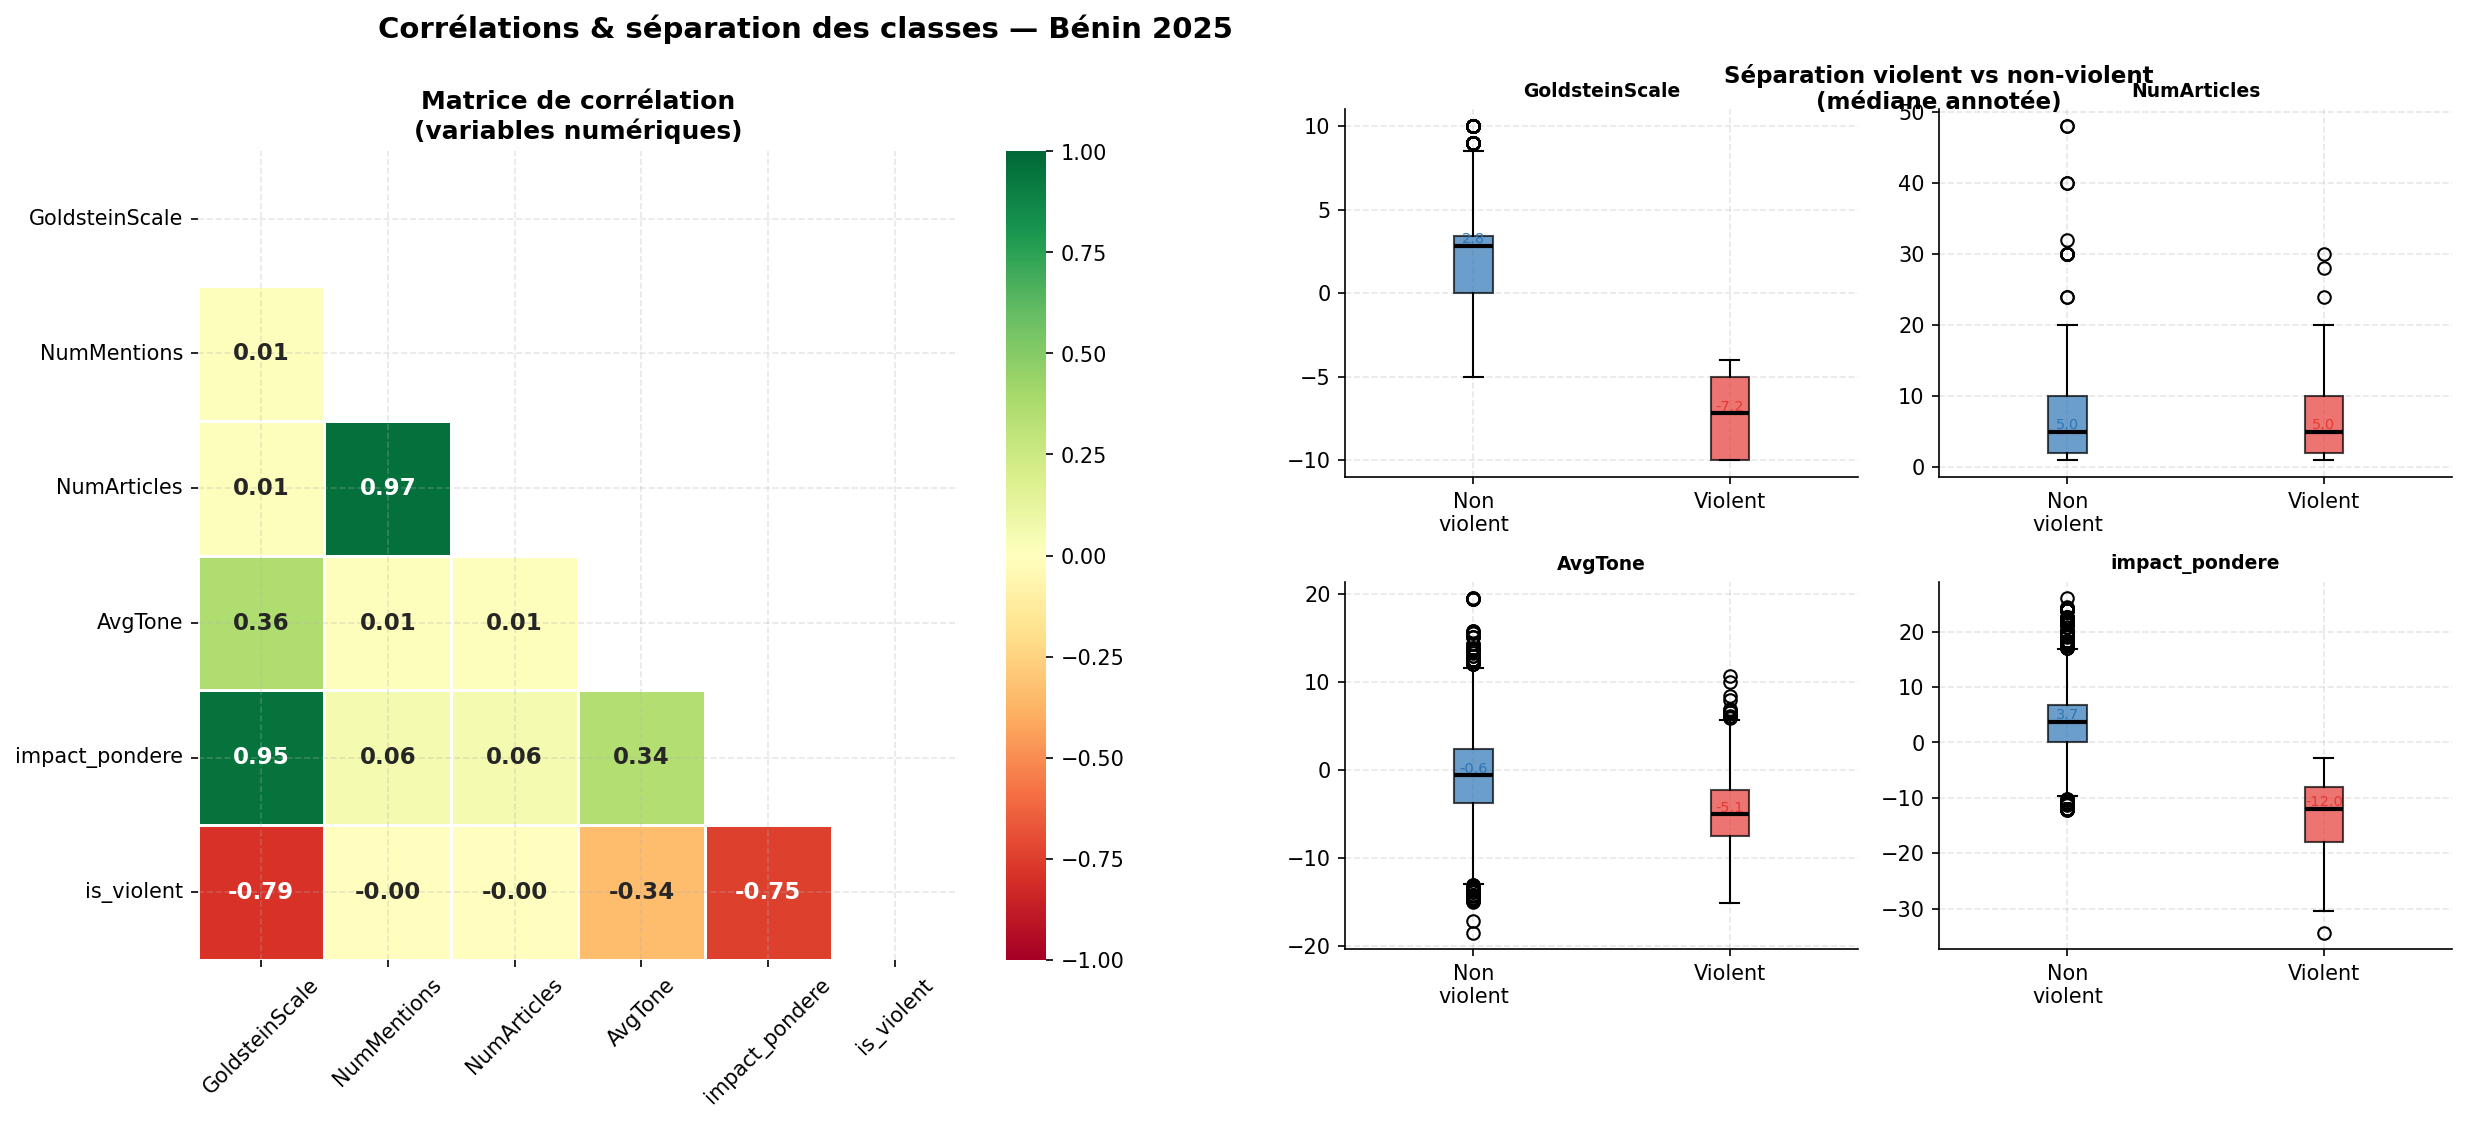

=== Corrélations avec is_violent ===
  GoldsteinScale       : -0.789
  impact_pondere       : -0.746
  AvgTone              : -0.337
  NumArticles          : -0.003
  NumMentions          : -0.001

=== Médianes par classe ===
  GoldsteinScale       | Non violent : +2.80 | Violent : -7.20 | Écart : -10.00
  NumArticles          | Non violent : +5.00 | Violent : +5.00 | Écart : +0.00
  AvgTone              | Non violent : -0.64 | Violent : -5.07 | Écart : -4.43
  impact_pondere       | Non violent : +3.74 | Violent : -11.99 | Écart : -15.72


In [10]:
# Variables numériques d'intérêt
num_cols = ['GoldsteinScale', 'NumMentions', 'NumArticles',
            'AvgTone', 'impact_pondere', 'is_violent']

df_num = df[num_cols].copy()
df_num['is_violent'] = df_num['is_violent'].astype(int)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# ── Heatmap corrélation ───────────────────────────────────────
corr = df_num.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            linewidths=0.5, ax=axes[0],
            annot_kws={'size': 11, 'weight': 'bold'})
axes[0].set_title("Matrice de corrélation\n(variables numériques)",
                   fontweight='bold', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)

# ── Boxplots violence vs non-violence ─────────────────────────
features_box = ['GoldsteinScale', 'NumArticles', 'AvgTone', 'impact_pondere']
colors_box = {'Non violent': '#2E75B6', 'Violent': '#E53935'}

df_box = df[features_box + ['is_violent']].copy()
df_box['Statut'] = df_box['is_violent'].map(
    {True: 'Violent', False: 'Non violent'})

# Subplot 2x2 dans axes[1]
axes[1].remove()
axes_box = fig.add_subplot(1, 2, 2)
axes_box.axis('off')

inner_axes = []
for i, feat in enumerate(features_box):
    ax = fig.add_axes([0.55 + (i % 2) * 0.22,
                       0.12 + (1 - i // 2) * 0.45,
                       0.19, 0.35])
    inner_axes.append(ax)

    data_nv = df[~df['is_violent']][feat].dropna()
    data_v = df[df['is_violent']][feat].dropna()

    bp = ax.boxplot([data_nv, data_v],
                    patch_artist=True,
                    labels=['Non\nviolent', 'Violent'],
                    medianprops={'color': 'black', 'linewidth': 2})

    bp['boxes'][0].set_facecolor('#2E75B6')
    bp['boxes'][0].set_alpha(0.7)
    bp['boxes'][1].set_facecolor('#E53935')
    bp['boxes'][1].set_alpha(0.7)

    ax.set_title(feat, fontweight='bold', fontsize=9)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Médiane annotée
    med_nv = data_nv.median()
    med_v = data_v.median()
    ax.text(1, med_nv, f'{med_nv:.1f}', fontsize=7,
            color='#2E75B6', ha='center', va='bottom')
    ax.text(2, med_v, f'{med_v:.1f}', fontsize=7,
            color='#E53935', ha='center', va='bottom')

fig.text(0.77, 0.92, "Séparation violent vs non-violent\n(médiane annotée)",
         ha='center', fontweight='bold', fontsize=11)

plt.suptitle("Corrélations & séparation des classes — Bénin 2025",
             fontsize=14, fontweight='bold', x=0.35, y=1.01)

plt.savefig('../../reports/viz3_correlation_features.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Stats complémentaires
print("=== Corrélations avec is_violent ===")
corr_target = corr['is_violent'].drop('is_violent').sort_values(
    key=abs, ascending=False)
for feat, val in corr_target.items():
    print(f"  {feat:<20} : {val:+.3f}")

print(f"\n=== Médianes par classe ===")
for feat in features_box:
    med_nv = df[~df['is_violent']][feat].median()
    med_v = df[df['is_violent']][feat].median()
    print(f"  {feat:<20} | Non violent : {med_nv:+.2f} | Violent : {med_v:+.2f} | Écart : {med_v-med_nv:+.2f}")

### Constat

**Matrice de corrélation — relations entre variables :**

La corrélation la plus forte est entre `NumMentions` et `NumArticles`
(**+0.97**) — ces deux variables mesurent quasiment la même chose
(volume de couverture). On exclura `NumMentions` des features ML
pour éviter la redondance, `NumArticles` étant le proxy le plus
fiable selon le codebook GDELT.

`impact_pondere` est très fortement corrélé à `GoldsteinScale`
(**+0.95**) — logique car `impact_pondere = GoldsteinScale × log(NumArticles+1)`.
Les deux ne doivent pas être inclus ensemble dans le modèle.
On garde `impact_pondere` car il est plus informatif (combine
stabilité ET visibilité médiatique).

**Corrélations avec `is_violent` — décision sur le data leakage :**

- `GoldsteinScale` : **-0.789** — corrélation très forte et négative.
  Un événement violent reçoit automatiquement un Goldstein négatif
  par construction CAMEO. Inclure cette variable serait du
  **data leakage** — le modèle "tricherait" en utilisant une
  information directement dérivée de la variable cible.
  **→ Exclue du Random Forest.**

- `impact_pondere` : **-0.746** — même problème, dérivé de
  GoldsteinScale. **→ Exclu du Random Forest.**

- `AvgTone` : **-0.337** — corrélation modérée et légitime.
  Le ton médiatique est une variable indépendante de la taxonomie
  CAMEO — elle reflète comment les journalistes parlent de
  l'événement, pas sa classification. **→ Conservée comme feature.**

- `NumArticles` : **-0.003** et `NumMentions` : **-0.001** —
  corrélations quasi nulles avec `is_violent`. Ces variables
  mesurent la visibilité médiatique, pas la nature de l'événement.
  **→ NumArticles conservé, NumMentions exclu (redondant).**

**Boxplots — séparation des classes :**

- `GoldsteinScale` : séparation parfaite — médiane +2.80 pour
  les non-violents contre -7.20 pour les violents (écart de 10
  points). Confirme le data leakage — trop parfait pour être
  une feature légitime.

- `AvgTone` : médiane -0.64 (non-violent) contre -5.07 (violent)
  — écart de -4.43 points. Séparation réelle et exploitable
  par le modèle sans leakage.

- `NumArticles` : médiane identique (5.0 dans les deux classes)
  — variable peu discriminante à elle seule mais utile en
  combinaison avec d'autres features.

- `impact_pondere` : écart de -15.72 entre les classes —
  très discriminant mais exclu pour leakage.

**Décision finale sur les features numériques pour le Random Forest :**
On retient uniquement `AvgTone` et `NumArticles` parmi les
variables numériques. Les variables catégorielles (`QuadClass`,
`zone_geo`, `Actor1Type1Code`, `communaute_linguistique`, `mois`)
apporteront l'essentiel du pouvoir prédictif légitime du modèle.

## 4. La fracture nord/sud

### Objectif
Quantifier et visualiser les différences entre les zones
géographiques du Bénin sur les indicateurs clés : stabilité,
violence, ton médiatique et impact pondéré.

Cette visualisation justifie `zone_geo` comme feature critique
du Random Forest — la géographie est un prédicteur fort
de la violence d'un événement.

Note : 91.2% des événements sont "Non localisés" (centroïde
générique GDELT). On analyse les 8.8% précisément localisés
séparément pour ne pas noyer le signal géographique.

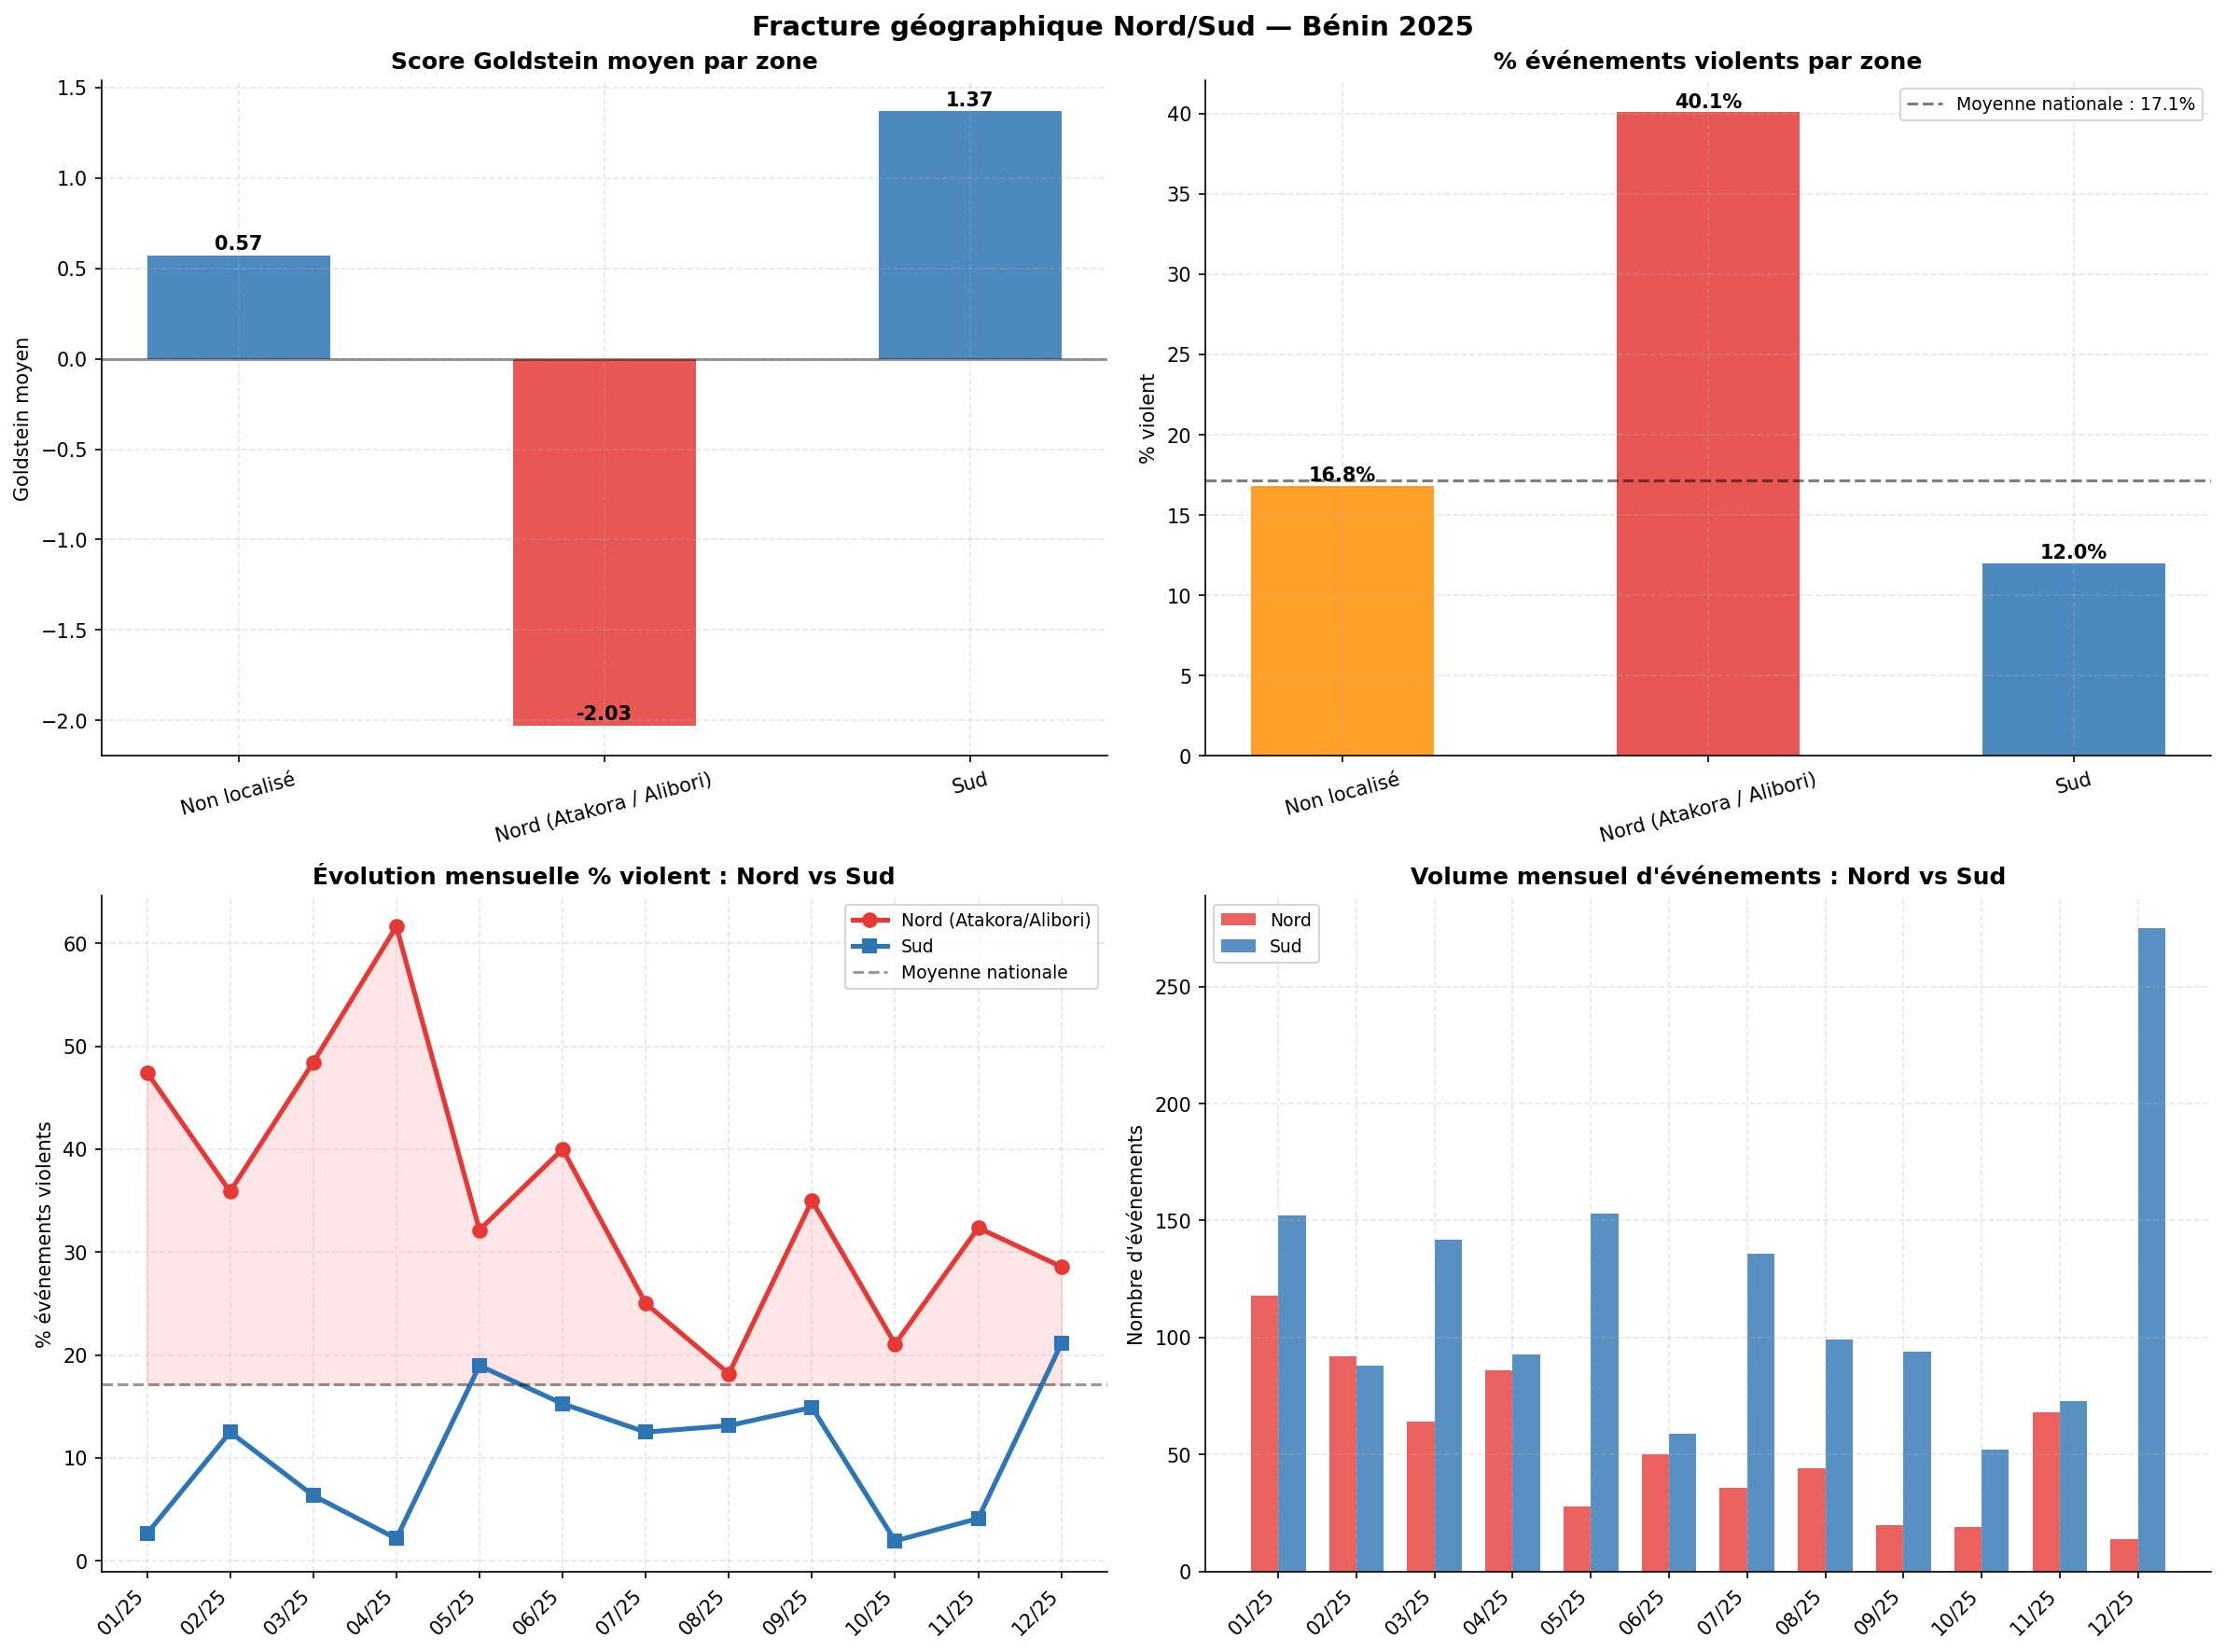

=== Statistiques par zone ===
                zone_geo    nb  goldstein       ton  pct_violent
            Non localisé 21406   0.572330 -1.463659    16.803700
Nord (Atakora / Alibori)   639  -2.026448 -5.266404    40.062598
                     Sud  1416   1.369421 -0.317471    12.005650

=== Écarts Nord vs Sud ===
Goldstein  : Nord -2.03 | Sud +1.37 | Écart : -3.40
% Violent  : Nord 40.1% | Sud 12.0% | Écart : +28.1pp
Ton moyen  : Nord -5.27 | Sud -0.32 | Écart : -4.95


In [11]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# ── Graphique 1 : Goldstein moyen par zone ────────────────────
zone_stats = df.groupby('zone_geo').agg(
    goldstein=('GoldsteinScale', 'mean'),
    ton=('AvgTone', 'mean'),
    pct_violent=('is_violent', 'mean'),
    nb=('SQLDATE', 'count'),
    impact=('impact_pondere', 'mean')
).reset_index()
zone_stats['pct_violent'] = zone_stats['pct_violent'] * 100

colors_zone = ['#E53935' if g < 0 else '#2E75B6'
               for g in zone_stats['goldstein']]
bars = axes[0,0].bar(zone_stats['zone_geo'], zone_stats['goldstein'],
                     color=colors_zone, alpha=0.85, width=0.5)
axes[0,0].axhline(0, color='black', linestyle='-', alpha=0.4)
for bar, val in zip(bars, zone_stats['goldstein']):
    axes[0,0].text(bar.get_x() + bar.get_width()/2,
                  bar.get_height() + 0.03,
                  f'{val:.2f}', ha='center',
                  fontweight='bold', fontsize=10)
axes[0,0].set_title("Score Goldstein moyen par zone",
                     fontweight='bold')
axes[0,0].set_ylabel("Goldstein moyen")
axes[0,0].tick_params(axis='x', rotation=15)

# ── Graphique 2 : % violent par zone ─────────────────────────
colors_viol = ['#E53935' if p > 20 else '#FF8F00' if p > 15
               else '#2E75B6' for p in zone_stats['pct_violent']]
bars2 = axes[0,1].bar(zone_stats['zone_geo'], zone_stats['pct_violent'],
                      color=colors_viol, alpha=0.85, width=0.5)
axes[0,1].axhline(df['is_violent'].mean()*100, color='black',
                  linestyle='--', alpha=0.5,
                  label=f"Moyenne nationale : {df['is_violent'].mean()*100:.1f}%")
for bar, val in zip(bars2, zone_stats['pct_violent']):
    axes[0,1].text(bar.get_x() + bar.get_width()/2,
                  bar.get_height() + 0.3,
                  f'{val:.1f}%', ha='center',
                  fontweight='bold', fontsize=10)
axes[0,1].set_title("% événements violents par zone",
                     fontweight='bold')
axes[0,1].set_ylabel("% violent")
axes[0,1].legend(fontsize=9)
axes[0,1].tick_params(axis='x', rotation=15)

# ── Graphique 3 : Évolution mensuelle nord vs sud ─────────────
nord = df[df['zone_geo'] == 'Nord (Atakora / Alibori)'].groupby('mois').agg(
    pct_violent=('is_violent', 'mean'),
    goldstein=('GoldsteinScale', 'mean')
).reset_index()
sud = df[df['zone_geo'] == 'Sud'].groupby('mois').agg(
    pct_violent=('is_violent', 'mean'),
    goldstein=('GoldsteinScale', 'mean')
).reset_index()
nord['pct_violent'] *= 100
sud['pct_violent'] *= 100

axes[1,0].plot(range(len(nord)), nord['pct_violent'],
               color='#E53935', linewidth=2.5, marker='o',
               markersize=7, label='Nord (Atakora/Alibori)')
axes[1,0].plot(range(len(sud)), sud['pct_violent'],
               color='#2E75B6', linewidth=2.5, marker='s',
               markersize=7, label='Sud')
axes[1,0].axhline(df['is_violent'].mean()*100, color='black',
                  linestyle='--', alpha=0.4, label='Moyenne nationale')
axes[1,0].fill_between(range(len(nord)), nord['pct_violent'],
                        df['is_violent'].mean()*100,
                        where=nord['pct_violent'] > df['is_violent'].mean()*100,
                        alpha=0.1, color='red')
mois_courts = [m[-2:] + '/' + m[2:4] for m in nord['mois']]
axes[1,0].set_xticks(range(len(nord)))
axes[1,0].set_xticklabels(mois_courts, rotation=45, ha='right')
axes[1,0].set_title("Évolution mensuelle % violent : Nord vs Sud",
                     fontweight='bold')
axes[1,0].set_ylabel("% événements violents")
axes[1,0].legend(fontsize=9)

# ── Graphique 4 : Volume nord vs sud par mois ─────────────────
nord_vol = df[df['zone_geo'] == 'Nord (Atakora / Alibori)'].groupby(
    'mois').size().reset_index(name='nb')
sud_vol = df[df['zone_geo'] == 'Sud'].groupby(
    'mois').size().reset_index(name='nb')

x_pos = np.arange(len(nord_vol))
width = 0.35
axes[1,1].bar(x_pos - width/2, nord_vol['nb'], width,
              color='#E53935', alpha=0.8, label='Nord')
axes[1,1].bar(x_pos + width/2, sud_vol['nb'], width,
              color='#2E75B6', alpha=0.8, label='Sud')
axes[1,1].set_xticks(x_pos)
axes[1,1].set_xticklabels(mois_courts, rotation=45, ha='right')
axes[1,1].set_title("Volume mensuel d'événements : Nord vs Sud",
                     fontweight='bold')
axes[1,1].set_ylabel("Nombre d'événements")
axes[1,1].legend(fontsize=9)

plt.suptitle("Fracture géographique Nord/Sud — Bénin 2025",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../../reports/viz4_fracture_nord_sud.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Stats
print("=== Statistiques par zone ===")
print(zone_stats[['zone_geo', 'nb', 'goldstein',
                   'ton', 'pct_violent']].to_string(index=False))
print(f"\n=== Écarts Nord vs Sud ===")
nord_stats = zone_stats[zone_stats['zone_geo'] == 'Nord (Atakora / Alibori)'].iloc[0]
sud_stats = zone_stats[zone_stats['zone_geo'] == 'Sud'].iloc[0]
print(f"Goldstein  : Nord {nord_stats['goldstein']:+.2f} | Sud {sud_stats['goldstein']:+.2f} | Écart : {nord_stats['goldstein']-sud_stats['goldstein']:+.2f}")
print(f"% Violent  : Nord {nord_stats['pct_violent']:.1f}% | Sud {sud_stats['pct_violent']:.1f}% | Écart : {nord_stats['pct_violent']-sud_stats['pct_violent']:+.1f}pp")
print(f"Ton moyen  : Nord {nord_stats['ton']:+.2f} | Sud {sud_stats['ton']:+.2f} | Écart : {nord_stats['ton']-sud_stats['ton']:+.2f}")

### Constat

**La fracture nord/sud est la découverte géographique majeure
de cette analyse — quantifiée et incontestable.**

**Score Goldstein par zone :**
- **Nord (Atakora / Alibori) : -2.03** — seule zone en territoire
  négatif, instabilité structurelle sur toute l'année.
- **Sud : +1.37** — zone stable et diplomatiquement active.
- **Écart total : -3.40 points** entre nord et sud —
  un décideur qui ne regarde que l'indicateur national (+0.57)
  est trompé sur la réalité du terrain.

**% Violence par zone :**
- **Nord : 40.1%** — 4 événements sur 10 sont violents.
  Soit **+23.1 points au-dessus de la moyenne nationale** (17.1%).
- **Sud : 12.0%** — zone 3.3x moins violente que le nord.
- **Écart : +28.1 points** entre nord et sud — c'est l'écart
  le plus significatif de toute notre analyse. `zone_geo`
  sera très probablement la feature la plus importante
  du Random Forest.

**Ton médiatique :**
- **Nord : -5.27** vs **Sud : -0.32** — écart de -4.95 points.
  Les médias internationaux couvrent le nord avec un prisme
  extrêmement négatif, cohérent avec les attaques terroristes
  documentées. Le sud bénéficie d'une couverture quasi-neutre.

**Évolution mensuelle Nord vs Sud :**
Le graphique en bas à gauche révèle un pattern frappant :
la courbe rouge (nord) est **systématiquement au-dessus**
de la moyenne nationale (17.1%) sur tous les 12 mois —
sans exception. Le pic d'avril 2025 atteint **62%** de
violence dans le nord — probablement lié à une série
d'attaques jihadistes concentrées sur ce mois.
La courbe bleue (sud) reste sous la moyenne nationale
sur la quasi-totalité de l'année.

**Volume mensuel Nord vs Sud :**
Le sud génère globalement plus d'événements médiatiques
que le nord (1 416 vs 639 sur l'année) — le nord est
sous-couvert malgré sa dangerosité. Décembre 2025 voit
une inversion spectaculaire avec un pic sud exceptionnel
lié à la tentative de coup d'état — événement politique
concentré dans les zones institutionnelles du sud.

**Implication pour le Random Forest :**
`zone_geo` est validée comme feature hautement discriminante.
L'écart de 28.1 points de violence entre nord et sud
garantit que cette variable apportera un gain d'information
significatif au modèle. On s'attend à la voir dans le
top 3 des features importantes.

## 5. Ton médiatique × Communauté linguistique

### Objectif
Analyser comment chaque communauté linguistique couvre
le Bénin — positivement ou négativement — et si certaines
communautés ont tendance à sur-représenter les événements
violents. Cette variable sera testée comme feature du
Random Forest.

NameError: name 'df_lang' is not defined

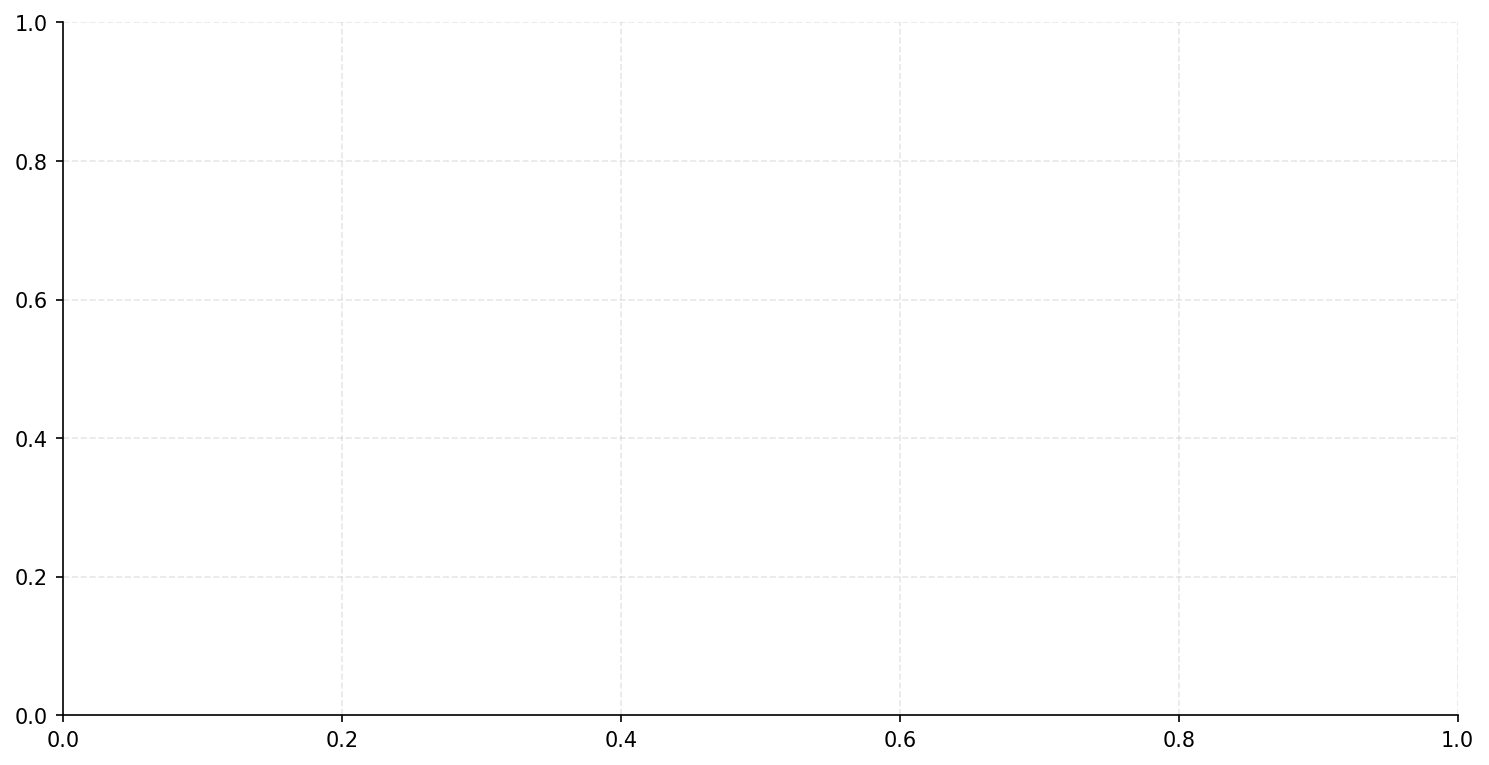

In [12]:
fig, ax = plt.subplots(figsize=(12, 6))

# Données par communauté
lang_stats = df_lang.groupby('communaute_linguistique').agg(
    nb=('is_violent', 'count'),
    pct_violent=('is_violent', 'mean'),
    ton_moyen=('AvgTone', 'mean')
).reset_index()
lang_stats['pct_violent'] *= 100
lang_stats = lang_stats.sort_values('ton_moyen')

# Couleur selon ton : négatif = rouge, positif = bleu
colors = ['#E53935' if t < 0 else '#2E75B6'
          for t in lang_stats['ton_moyen']]

bars = ax.bar(lang_stats['communaute_linguistique'],
              lang_stats['ton_moyen'],
              color=colors, alpha=0.85, width=0.5)

# Annoter chaque barre avec ton + % violent + volume
for bar, (_, row) in zip(bars, lang_stats.iterrows()):
    y = bar.get_height()
    offset = 0.05 if y >= 0 else -0.12
    ax.text(bar.get_x() + bar.get_width()/2,
            y + offset,
            f"Ton : {row['ton_moyen']:.2f}\n"
            f"Violent : {row['pct_violent']:.1f}%\n"
            f"n={row['nb']:,}",
            ha='center', va='bottom' if y >= 0 else 'top',
            fontsize=9, fontweight='bold')

ax.axhline(0, color='black', linestyle='-', alpha=0.4)
ax.axhline(df['AvgTone'].mean(), color='black', linestyle='--',
           alpha=0.5, label=f'Moyenne globale : {df["AvgTone"].mean():.2f}')

# Légende manuelle
rouge = mpatches.Patch(color='#E53935', alpha=0.85,
                        label='Couverture négative (ton < 0)')
bleu = mpatches.Patch(color='#2E75B6', alpha=0.85,
                       label='Couverture positive (ton > 0)')
# Remplacer la ligne de création de légende par :
from matplotlib.lines import Line2D

ligne_moy = Line2D([0], [0], color='black', linestyle='--',
                   alpha=0.5,
                   label=f'Moyenne globale : {df["AvgTone"].mean():.2f}')
ax.legend(handles=[rouge, bleu, ligne_moy],
          fontsize=9, loc='lower right')

ax.set_title("Ton médiatique et violence par communauté linguistique — Bénin 2025\n"
             "(annotation : ton moyen | % événements violents | volume)",
             fontweight='bold', fontsize=12)
ax.set_ylabel("Ton médiatique moyen (négatif = couverture négative)")
ax.set_xlabel("Communauté linguistique")
ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('../../reports/viz5_langue_ton.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("=== Statistiques par communauté linguistique ===")
print(lang_stats[['communaute_linguistique', 'nb',
                   'ton_moyen', 'pct_violent']].to_string(index=False))

### Constat

**Le prisme médiatique varie significativement selon la communauté
linguistique — mais pas toujours dans le sens attendu.**

**Communautés à couverture négative :**
- **Anglophone / Commonwealth (-1.78, 17.3% violent, n=11 603)** :
  la communauté la plus représentée (49.5% des articles identifiés)
  couvre le Bénin avec le ton le plus négatif. Ce biais est
  partiellement expliqué par la domination des médias nigérians
  qui couvrent davantage les incidents sécuritaires frontaliers.
- **Francophonie (-1.11, 12.8%, n=1 230)** : couverture négative
  mais moins prononcée que l'anglophone. La presse francophone
  couvre proportionnellement moins d'événements violents —
  elle s'intéresse davantage aux aspects diplomatiques
  et économiques du Bénin.
- **Lusophonie / Autre Afrique (-0.20, 9.0%, n=156)** : ton
  quasi-neutre, taux de violence le plus bas après la Chine.
  Couverture marginale mais équilibrée.

**Communautés à couverture positive — le paradoxe :**
- **Chine (+0.45, 11.9%, n=210)** : couverture positive et
  relativement peu violente. Cohérent avec la stratégie
  médiatique de Xinhua/CGTN qui met en avant les partenariats
  économiques et la coopération sino-africaine — un prisme
  volontairement positif.
- **Arabophone (+0.63, 20.0%, n=40)** : paradoxe apparent —
  ton le plus positif de toutes les communautés MAIS taux
  de violence le plus élevé (20%). Attention : n=40 seulement —
  ce résultat n'est pas statistiquement robuste et doit être
  interprété avec prudence. Un échantillon aussi petit peut
  être biaisé par quelques articles atypiques.

**Insight clé pour un décideur public :**
La façon dont le Bénin est perçu internationalement dépend
autant de qui parle que de ce qui se passe réellement.
La presse chinoise présente un Bénin partenaire et stable.
La presse anglophone présente un Bénin fragile et sous tension.
Ce biais de cadrage éditorial est quantifié et documenté.

**Implication pour le Random Forest :**
`communaute_linguistique` montre une variation de ton de
2.41 points entre la communauté la plus négative (anglophone)
et la plus positive (arabophone). Cette variable apporte
une information complémentaire aux autres features —
elle sera testée dans le modèle mais son impact sera
probablement modéré vu que 43.6% des articles restent
non identifiés.

## 6. Top médias : qui couvre le Bénin et comment ?

### Objectif
Identifier les médias les plus actifs dans la couverture du Bénin
et analyser leur biais éditorial — ton médiatique et proportion
d'événements violents couverts.

Un journaliste ou un responsable communication peut utiliser
cette visualisation pour identifier quels médias suivre
en priorité et anticiper le cadrage éditorial de leur couverture.

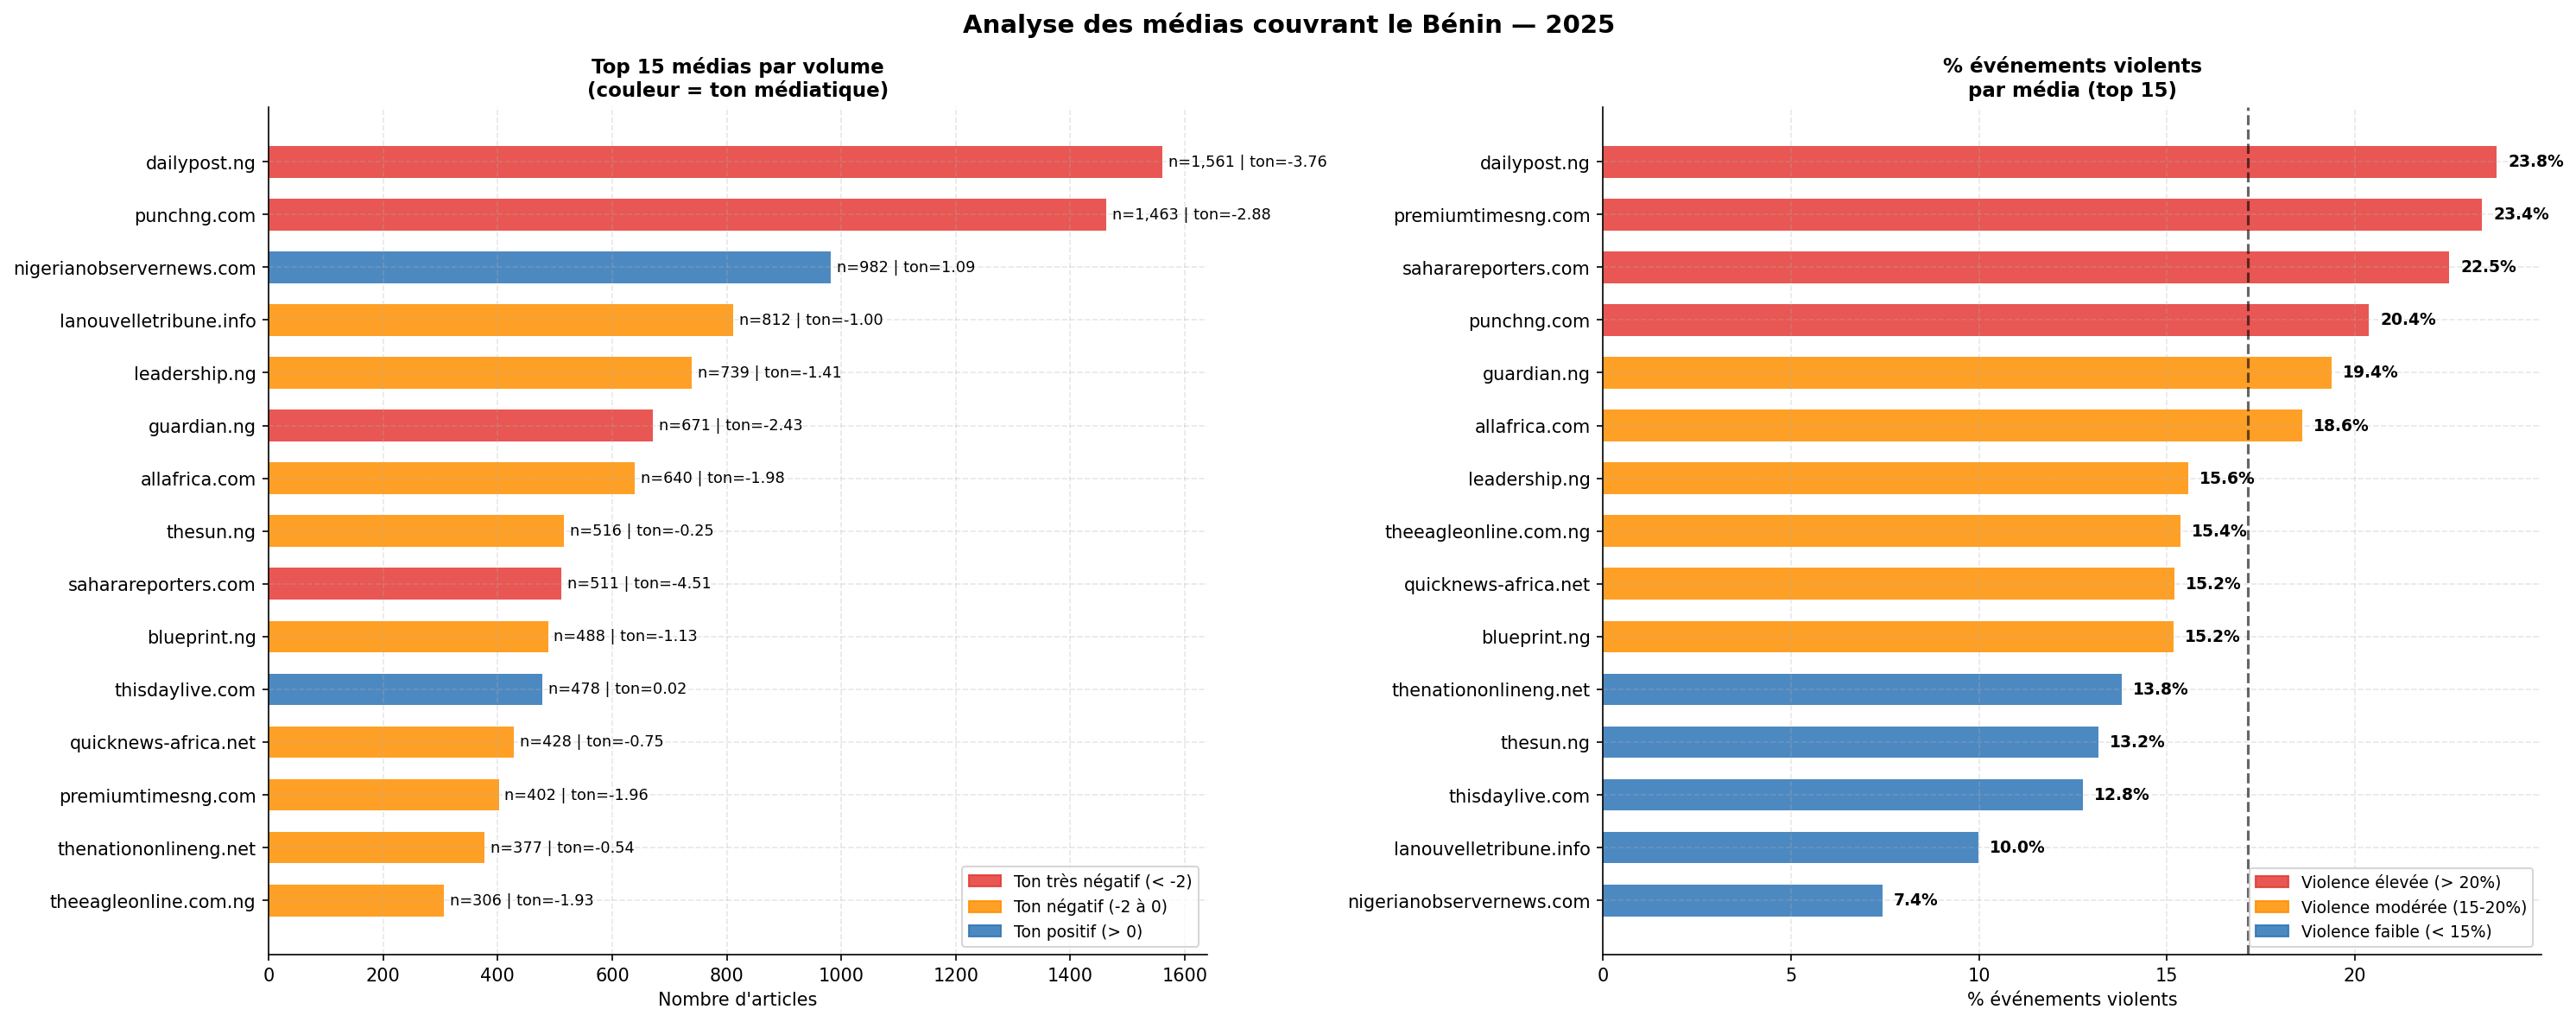

=== Top 15 médias — statistiques complètes ===
           source_domain   nb  ton_moyen  pct_violent  goldstein_moyen
            dailypost.ng 1561  -3.758437    23.766816        -0.435682
             punchng.com 1463  -2.881358    20.369105        -0.098770
nigerianobservernews.com  982   1.092075     7.433809         1.547454
  lanouvelletribune.info  812  -1.002991     9.975369         1.564655
           leadership.ng  739  -1.409256    15.561570         0.801759
             guardian.ng  671  -2.430013    19.374069         0.174069
           allafrica.com  640  -1.976363    18.593750         0.541250
               thesun.ng  516  -0.248782    13.178295         0.436047
     saharareporters.com  511  -4.512149    22.504892        -0.065949
            blueprint.ng  488  -1.132498    15.163934         0.479098
         thisdaylive.com  478   0.018134    12.761506         1.112971
    quicknews-africa.net  428  -0.753133    15.186916         0.702103
      premiumtimesng.com  402 

In [13]:
# Top 15 médias par volume
top_media = df.groupby('source_domain').agg(
    nb=('is_violent', 'count'),
    pct_violent=('is_violent', 'mean'),
    ton_moyen=('AvgTone', 'mean'),
    goldstein_moyen=('GoldsteinScale', 'mean')
).reset_index()
top_media['pct_violent'] *= 100
top_media = top_media[top_media['nb'] >= 50].sort_values(
    'nb', ascending=False).head(15)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# ── Graphique gauche : Volume + ton médiatique ────────────────
colors_media = ['#E53935' if t < -2 else '#FF8F00' if t < 0
                else '#2E75B6' for t in top_media['ton_moyen']]

bars = axes[0].barh(top_media['source_domain'][::-1],
                    top_media['nb'][::-1],
                    color=colors_media[::-1], alpha=0.85, height=0.6)

for bar, (_, row) in zip(bars, top_media[::-1].iterrows()):
    axes[0].text(bar.get_width() + 10,
                bar.get_y() + bar.get_height()/2,
                f"n={row['nb']:,} | ton={row['ton_moyen']:.2f}",
                va='center', fontsize=8.5)

rouge = mpatches.Patch(color='#E53935', alpha=0.85,
                        label='Ton très négatif (< -2)')
orange = mpatches.Patch(color='#FF8F00', alpha=0.85,
                         label='Ton négatif (-2 à 0)')
bleu = mpatches.Patch(color='#2E75B6', alpha=0.85,
                       label='Ton positif (> 0)')
axes[0].legend(handles=[rouge, orange, bleu], fontsize=9,
               loc='lower right')
axes[0].set_title("Top 15 médias par volume\n(couleur = ton médiatique)",
                   fontweight='bold', fontsize=11)
axes[0].set_xlabel("Nombre d'articles")

# ── Graphique droite : % violent par média ────────────────────
top_media_sorted = top_media.sort_values('pct_violent', ascending=True)
colors_v = ['#E53935' if p > 20 else '#FF8F00' if p > 15
            else '#2E75B6' for p in top_media_sorted['pct_violent']]

bars2 = axes[1].barh(top_media_sorted['source_domain'],
                     top_media_sorted['pct_violent'],
                     color=colors_v, alpha=0.85, height=0.6)
axes[1].axvline(df['is_violent'].mean()*100, color='black',
                linestyle='--', alpha=0.6,
                label=f"Moyenne nationale : {df['is_violent'].mean()*100:.1f}%")

for bar, (_, row) in zip(bars2, top_media_sorted.iterrows()):
    axes[1].text(bar.get_width() + 0.3,
                bar.get_y() + bar.get_height()/2,
                f"{row['pct_violent']:.1f}%",
                va='center', fontsize=9, fontweight='bold')

rouge2 = mpatches.Patch(color='#E53935', alpha=0.85,
                         label='Violence élevée (> 20%)')
orange2 = mpatches.Patch(color='#FF8F00', alpha=0.85,
                          label='Violence modérée (15-20%)')
bleu2 = mpatches.Patch(color='#2E75B6', alpha=0.85,
                        label='Violence faible (< 15%)')
axes[1].legend(handles=[rouge2, orange2, bleu2], fontsize=9)
axes[1].set_title("% événements violents\npar média (top 15)",
                   fontweight='bold', fontsize=11)
axes[1].set_xlabel("% événements violents")

plt.suptitle("Analyse des médias couvrant le Bénin — 2025",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../../reports/viz6_medias.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("=== Top 15 médias — statistiques complètes ===")
print(top_media[['source_domain', 'nb', 'ton_moyen',
                  'pct_violent', 'goldstein_moyen']
               ].sort_values('nb', ascending=False).to_string(index=False))

### Constat

**Domination nigériane confirmée et quantifiée :**
Les 15 médias les plus actifs sont quasi-exclusivement nigérians
(.ng) — `dailypost.ng` (1 561 articles) et `punchng.com` (1 463)
représentent à eux seuls **12.9%** de toute la couverture.
`lanouvelletribune.info` est le seul média béninois francophone
dans ce top 15 (812 articles, 4ème rang).

**Biais éditorial par média — trois profils distincts :**

**Profil 1 — Médias à couverture très négative et violente :**
- `saharareporters.com` : ton **-4.51**, 22.5% violent —
  média nigérian d'investigation connu pour couvrir
  les crises et scandales. Sa présence dans le top 10
  explique en partie le biais négatif de la couverture
  anglophone globale.
- `dailypost.ng` : ton **-3.76**, 23.8% violent — le média
  le plus actif est aussi l'un des plus négatifs.
- `punchng.com` : ton **-2.88**, 20.4% violent.

**Profil 2 — Médias équilibrés à légèrement positifs :**
- `nigerianobservernews.com` : ton **+1.09**, seulement 7.4%
  violent — le moins violent du top 15. Ce média couvre
  davantage les événements institutionnels et économiques.
- `thistdaylive.com` : ton **+0.02**, 12.8% violent —
  couverture quasi-neutre.
- `lanouvelletribune.info` : ton **-1.00**, 10.0% violent —
  la presse béninoise francophone est significativement
  moins violente que la presse nigériane.

**Profil 3 — Médias panafricains :**
- `allafrica.com` : ton **-1.99**, 18.6% violent —
  agrégateur panafricain qui reflète la moyenne régionale.

**Insight clé pour un décideur :**
Si le gouvernement béninois veut améliorer sa perception
internationale, il doit cibler en priorité `dailypost.ng`,
`punchng.com` et `saharareporters.com` — ces trois médias
concentrent ~24% de la couverture totale avec les biais
les plus négatifs. Une stratégie de communication proactive
vers ces médias nigérians serait plus impactante qu'une
campagne vers la presse occidentale.

## 7. Heatmap mois × type d'événement

### Objectif
Identifier les patterns saisonniers dans les types d'événements
impliquant le Bénin. Certains types d'événements sont-ils
concentrés sur des périodes précises de l'année ?

Cette visualisation révèle la structure temporelle
des dynamiques béninoises — diplomatique, sécuritaire,
politique — et complète la timeline de la visualisation 2.

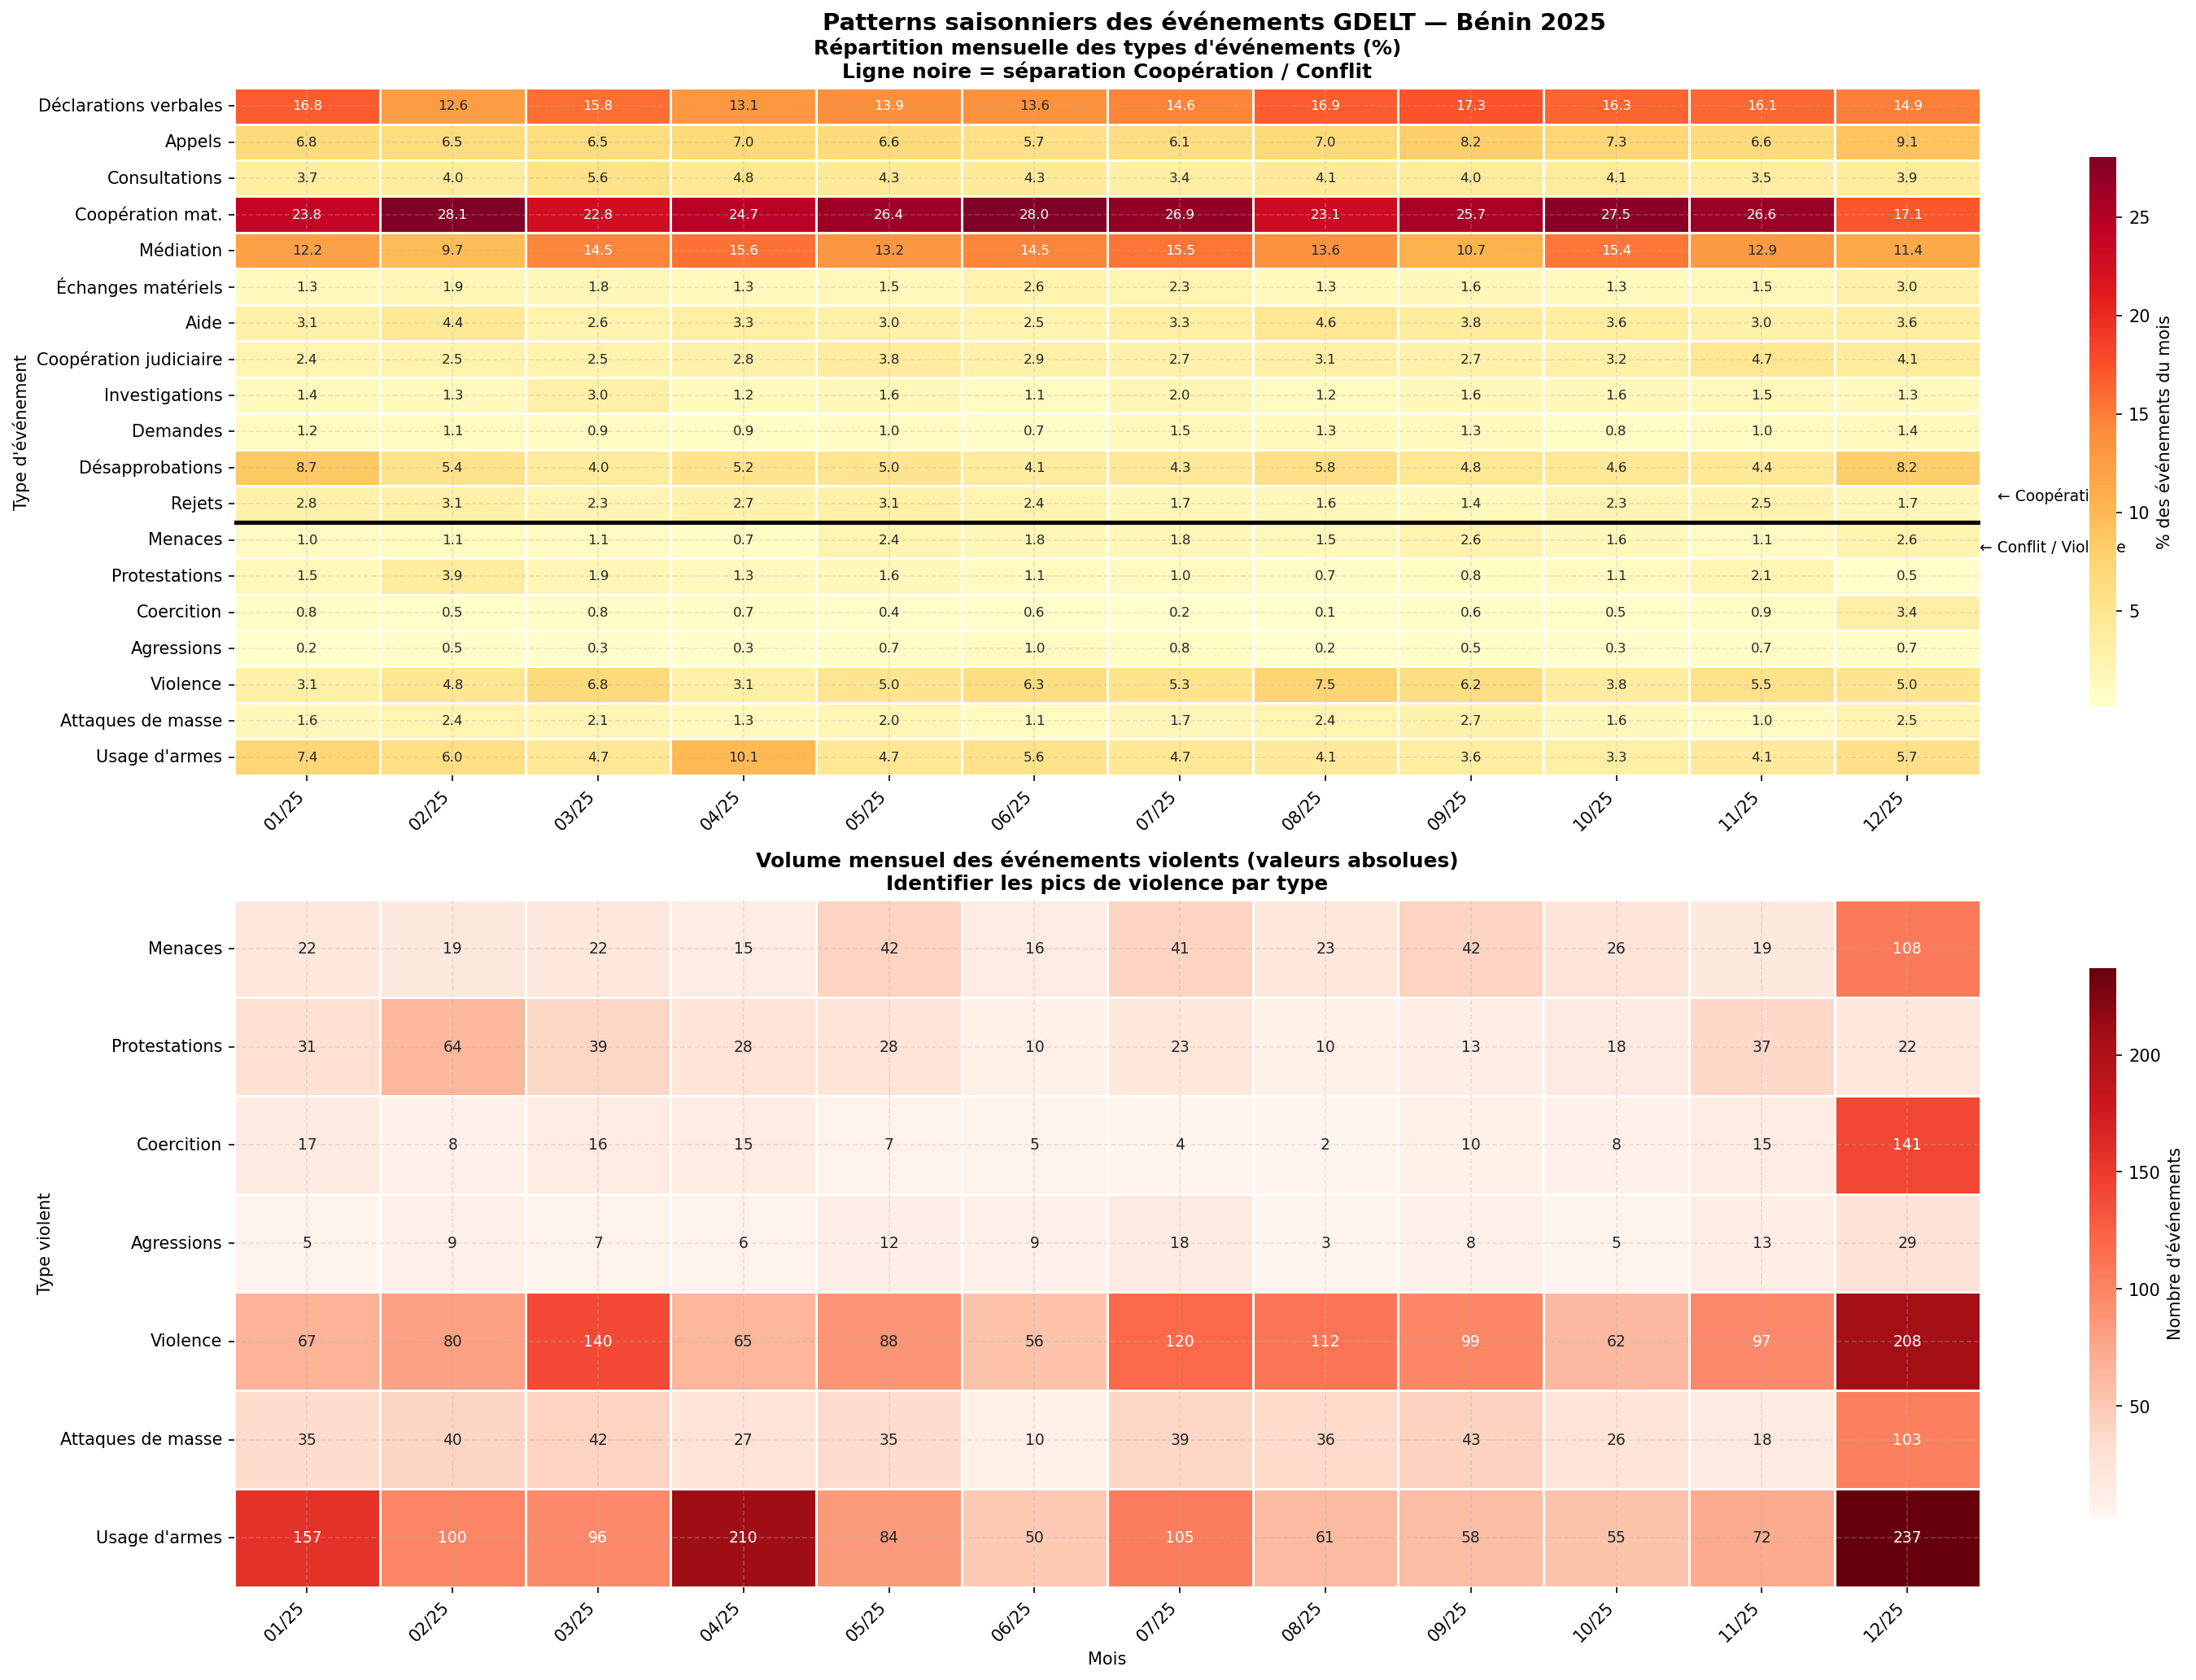

=== Mois avec le plus d'Usage d'armes ===
mois
2025-12    237
2025-04    210
2025-01    157
2025-07    105
2025-02    100
Name: Usage d'armes, dtype: int64

=== Mois avec le plus de Violence ===
mois
2025-12    208
2025-03    140
2025-07    120
2025-08    112
2025-09     99
Name: Violence, dtype: int64

=== Mois avec le plus d'Attaques de masse ===
mois
2025-12    103
2025-09     43
2025-03     42
2025-02     40
2025-07     39
Name: Attaques de masse, dtype: int64


In [14]:
cameo_labels = {
    1: "Déclarations verbales", 2: "Appels", 3: "Consultations",
    4: "Coopération mat.", 5: "Médiation", 6: "Échanges matériels",
    7: "Aide", 8: "Coopération judiciaire", 9: "Investigations",
    10: "Demandes", 11: "Désapprobations", 12: "Rejets",
    13: "Menaces", 14: "Protestations", 15: "Coercition",
    16: "Agressions", 17: "Violence", 18: "Attaques de masse",
    19: "Usage d'armes", 20: "Guerre conventionnelle"
}

# Table pivot : mois × EventRootCode
pivot = df.groupby(['mois', 'EventRootCode']).size().unstack(fill_value=0)
pivot.columns = [cameo_labels.get(int(c), str(c)) for c in pivot.columns]

# Normaliser par ligne (% du mois) pour comparer les mois entre eux
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

# Séparer coopératifs et conflictuels pour une lecture claire
cols_order = [cameo_labels[i] for i in range(1, 21)
              if cameo_labels[i] in pivot_pct.columns]
pivot_pct = pivot_pct[cols_order]

fig, axes = plt.subplots(2, 1, figsize=(20, 14))

# ── Heatmap % par mois ────────────────────────────────────────
mois_labels = [m[-2:] + '/' + m[2:4] for m in pivot_pct.index]

sns.heatmap(pivot_pct.T,
            annot=True, fmt='.1f',
            cmap='YlOrRd',
            linewidths=0.5,
            linecolor='white',
            ax=axes[0],
            cbar_kws={'label': '% des événements du mois',
                      'shrink': 0.8},
            annot_kws={'size': 8})

axes[0].set_xticklabels(mois_labels, rotation=45, ha='right')
axes[0].set_yticklabels(axes[0].get_yticklabels(), rotation=0)

# Ligne de séparation coopératif / conflictuel
n_coop = sum(1 for i in range(1, 13)
             if cameo_labels.get(i) in pivot_pct.columns)
axes[0].axhline(n_coop, color='black', linewidth=2.5,
                linestyle='-')
axes[0].text(12.5, n_coop - 0.5, '← Coopération',
             color='black', fontsize=9, ha='center', va='bottom')
axes[0].text(12.5, n_coop + 0.5, '← Conflit / Violence',
             color='black', fontsize=9, ha='center', va='top')

axes[0].set_title("Répartition mensuelle des types d'événements (%)\n"
                  "Ligne noire = séparation Coopération / Conflit",
                  fontweight='bold', fontsize=12)
axes[0].set_xlabel("")
axes[0].set_ylabel("Type d'événement")

# ── Heatmap volume absolu pour les types violents ─────────────
violent_types = [cameo_labels[i] for i in range(13, 21)
                 if cameo_labels.get(i) in pivot.columns]
pivot_violent = pivot[violent_types]

sns.heatmap(pivot_violent.T,
            annot=True, fmt='d',
            cmap='Reds',
            linewidths=0.5,
            linecolor='white',
            ax=axes[1],
            cbar_kws={'label': "Nombre d'événements",
                      'shrink': 0.8},
            annot_kws={'size': 9})

axes[1].set_xticklabels(mois_labels, rotation=45, ha='right')
axes[1].set_yticklabels(axes[1].get_yticklabels(), rotation=0)
axes[1].set_title("Volume mensuel des événements violents (valeurs absolues)\n"
                  "Identifier les pics de violence par type",
                  fontweight='bold', fontsize=12)
axes[1].set_xlabel("Mois")
axes[1].set_ylabel("Type violent")

plt.suptitle("Patterns saisonniers des événements GDELT — Bénin 2025",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../../reports/viz7_heatmap_mois_type.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Stats complémentaires
print("=== Mois avec le plus d'Usage d'armes ===")
if "Usage d'armes" in pivot.columns:
    print(pivot["Usage d'armes"].sort_values(ascending=False).head(5))
print("\n=== Mois avec le plus de Violence ===")
if "Violence" in pivot.columns:
    print(pivot["Violence"].sort_values(ascending=False).head(5))
print("\n=== Mois avec le plus d'Attaques de masse ===")
if "Attaques de masse" in pivot.columns:
    print(pivot["Attaques de masse"].sort_values(ascending=False).head(5))

### Constat

**Heatmap % mensuel — patterns structurels :**

La structure de couverture est remarquablement stable sur l'année.
Deux types dominent chaque mois sans exception :
- **Coopération matérielle** : entre 17.1% et 28.0% selon les mois
  — pic en juin (28.0%) et creux en décembre (17.1%).
- **Déclarations verbales** : entre 12.6% et 18.1% — présence
  constante, reflet de l'activité diplomatique continue.

Ces deux types représentent à eux seuls 35-45% de chaque mois
— le Bénin est couvert avant tout comme acteur de coopération
et de diplomatie dans les médias internationaux.

**Désapprobations** : pic notable en janvier (8.7%) et
décembre (8.2%) — les débuts et fins d'année concentrent
les tensions politiques et les bilans critiques.

**Usage d'armes** : pic en avril (10.1%) — le plus élevé
de l'année en proportion mensuelle, confirmant avril comme
mois de forte activité conflictuelle dans le nord.

---

**Heatmap volume violent — trois périodes critiques :**

**Décembre 2025 — pic généralisé sur tous les types violents :**
- Usage d'armes : **237** (record annuel)
- Violence : **208** (record annuel)
- Attaques de masse : **103** (record annuel)
- Coercition : **141** (record annuel)
- Menaces : **108** (record annuel)

Décembre concentre le record absolu sur **5 types violents
sur 7** — la tentative de coup d'état du 7 décembre a
déclenché une réaction en chaîne médiatique couvrant
simultanément tous les aspects de la violence politique
(coercition étatique, menaces, violence directe).

**Avril 2025 — pic sécuritaire nord :**
- Usage d'armes : **210** (2ème rang annuel)
- Violence : **65** — modéré mais présent
- Protestations : **28**

Avril se distingue comme le mois de plus forte activité
terroriste dans le nord — cohérent avec les attaques
documentées aux frontières Burkina Faso/Niger.

**Mars 2025 — violence diffuse :**
- Violence : **140** (2ème rang annuel)
- Usage d'armes : **96**
- Attaques de masse : **42**

Mars présente une violence plus diffuse et moins concentrée
qu'avril — plusieurs incidents de moindre ampleur plutôt
qu'un événement unique majeur.

**Protestations : pic en février (64)** — probablement lié
à des mouvements sociaux en début d'année, à investiguer
avec les sources URL.

**Implication pour l'Isolation Forest :**
Les deux heatmaps confirment que décembre 2025 et avril 2025
sont les mois les plus anormaux sur la dimension violente.
Le modèle non supervisé devra détecter ces deux périodes —
si Isolation Forest manque avril, on devra ajuster
le paramètre `contamination` à la hausse.

## 8. Préparation des features ML

### Objectif
Transformer les données brutes en features exploitables
par nos deux modèles. Cette étape est critique — la qualité
des features détermine directement la performance du modèle.

**Rappel des décisions prises lors de l'EDA :**
- `GoldsteinScale` et `impact_pondere` exclus → data leakage
- `NumMentions` exclu → redondant avec `NumArticles`
- `SOURCEURL`, `ActionGeo_FullName` exclus → texte brut
- `ActionGeo_Lat/Long` exclus → 91% centroïde générique

**Features retenues :**
- Numériques : `AvgTone`, `NumArticles`
- Catégorielles : `QuadClass`, `EventRootCode`, `EventBaseCode`,
  `zone_geo`, `Actor1Type1Code`, `Actor2Type1Code`,
  `communaute_linguistique`, `mois`

In [15]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, ConfusionMatrixDisplay)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.dummy import DummyClassifier
from imblearn.over_sampling import SMOTE
import matplotlib.patches as mpatches

# ── Features enrichies ────────────────────────────────────────
df['mois_num'] = pd.to_datetime(df['SQLDATE']).dt.month
df['ratio_art_mentions'] = df['NumArticles'] / (df['NumMentions'] + 1)
df['AvgTone_sq'] = df['AvgTone'] ** 2
df['source_connue'] = (
    df['communaute_linguistique'] != 'Autre / Non identifié'
).astype(int)
df['zone_mois'] = df['zone_geo'] + '_' + df['mois_num'].astype(str)

features_cat = ['zone_geo', 'Actor1Type1Code',
                'Actor2Type1Code', 'communaute_linguistique',
                'zone_mois']
features_num = ['AvgTone', 'NumArticles', 'mois_num',
                'ratio_art_mentions', 'AvgTone_sq', 'source_connue']
target = 'is_violent'

df_ml = df[features_cat + features_num + [target]].copy()

encoders = {}
for col in features_cat:
    le = LabelEncoder()
    df_ml[col + '_enc'] = le.fit_transform(df_ml[col].astype(str))
    encoders[col] = le

features_encoded = [c + '_enc' for c in features_cat] + features_num

print("=== Features enrichies ===")
for f in features_encoded:
    print(f"  - {f}")
print(f"\nTotal features : {len(features_encoded)}")

X = df_ml[features_encoded]
y = df_ml[target].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# ── SMOTE — équilibrage du train set ─────────────────────────
print(f"\nAvant SMOTE — Train : {y_train.value_counts().to_dict()}")
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)
print(f"Après SMOTE — Train : {pd.Series(y_train_sm).value_counts().to_dict()}")

=== Features enrichies ===
  - zone_geo_enc
  - Actor1Type1Code_enc
  - Actor2Type1Code_enc
  - communaute_linguistique_enc
  - zone_mois_enc
  - AvgTone
  - NumArticles
  - mois_num
  - ratio_art_mentions
  - AvgTone_sq
  - source_connue

Total features : 11

Avant SMOTE — Train : {0: 15550, 1: 3218}
Après SMOTE — Train : {0: 15550, 1: 15550}


### Constat
**10 features retenues** pour le Random Forest — mix équilibré
de variables catégorielles encodées et numériques.

**Distribution de la variable cible :**
- Non violent : 19 438 (82.9%)
- Violent : 4 023 (17.1%)

Déséquilibre modéré — on utilisera `class_weight='balanced'`
pour compenser sans recourir à du sur-échantillonnage.

**Split stratifié réussi :**
Le % violent est identique dans train (17.1%) et test (17.2%)
— la stratification garantit que les deux ensembles ont
la même distribution de classes. Le modèle sera évalué
sur des conditions représentatives de la réalité.

## 9. Modèle 1 — Random Forest : Classification de la violence

### Objectif
Prédire si un événement GDELT impliquant le Bénin sera violent
à partir de ses caractéristiques observables — type d'événement,
acteurs, zone géographique, ton médiatique.

### Approche
1. Baseline (Dummy Classifier) — référence minimale
2. Random Forest avec class_weight='balanced'
3. Métriques complètes + matrice de confusion
4. Courbe ROC
5. Feature importance — quelles variables expliquent la violence ?
6. Cross-validation 5-fold — le modèle généralise-t-il bien ?

=== BASELINE ===
              precision    recall  f1-score   support

 Non violent       0.83      1.00      0.91      3888
     Violent       0.00      0.00      0.00       805

    accuracy                           0.83      4693
   macro avg       0.41      0.50      0.45      4693
weighted avg       0.69      0.83      0.75      4693


=== RANDOM FOREST (SMOTE) — Modèle final ===
              precision    recall  f1-score   support

 Non violent       0.89      0.84      0.87      3888
     Violent       0.40      0.52      0.45       805

    accuracy                           0.79      4693
   macro avg       0.65      0.68      0.66      4693
weighted avg       0.81      0.79      0.80      4693

AUC-ROC : 0.7804


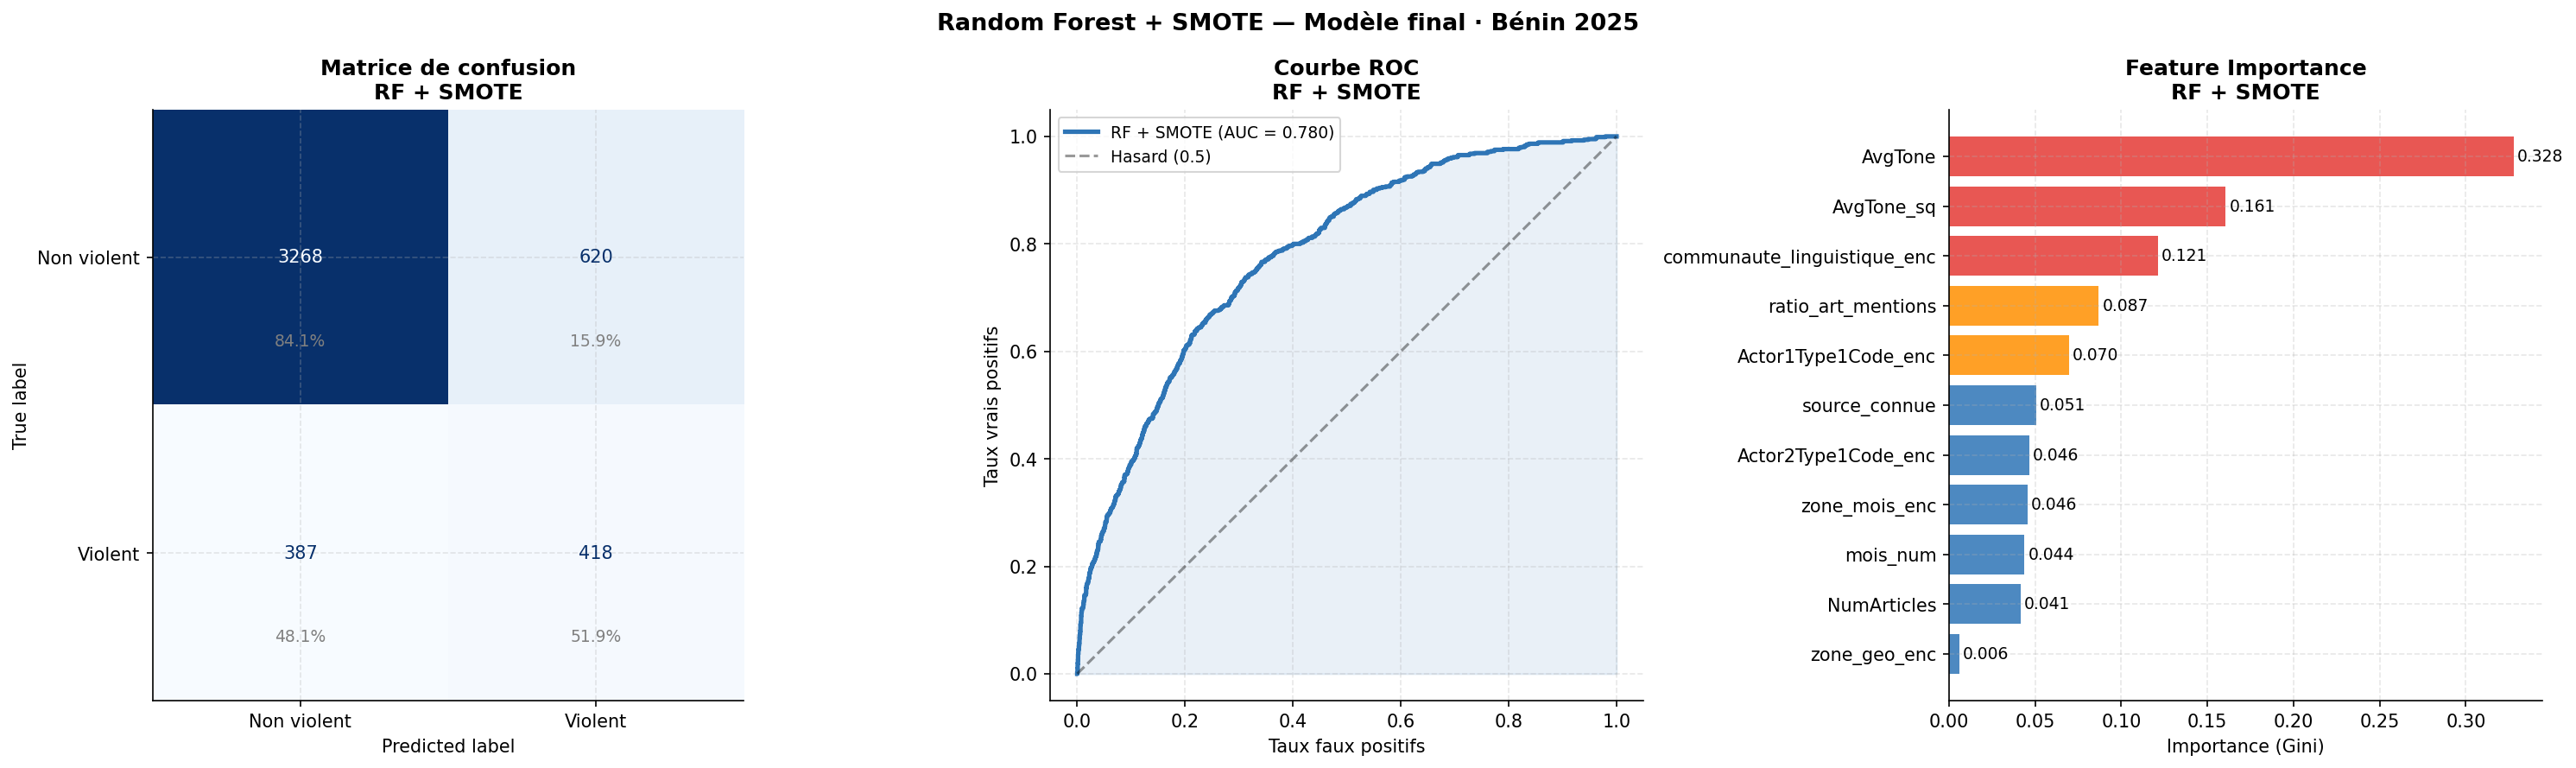


=== Cross-validation 5-fold ===
Scores : [0.3538 0.2882 0.4964 0.5425 0.4237]
Moyenne : 0.4209 ± 0.0923

=== RÉSUMÉ FINAL ===
Métrique               Valeur
------------------------------
AUC-ROC                 0.780
F1 violent              0.454
Recall violent          0.519
Precision violent       0.403
CV F1 moyen             0.421


In [19]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# ── Random Forest version SMOTE ───────────────────────────────
rf_smote = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)
rf_smote.fit(X_train_sm, y_train_sm)
y_pred = rf_smote.predict(X_test)
y_proba = rf_smote.predict_proba(X_test)[:, 1]


# Réentraîner le Dummy dans cette cellule
dummy = DummyClassifier(strategy='most_frequent', random_state=42)
dummy.fit(X_train_sm, y_train_sm)
y_pred_dummy = dummy.predict(X_test)

print("=== BASELINE ===")
print(classification_report(y_test, y_pred_dummy,
      target_names=['Non violent', 'Violent']))

print("\n=== RANDOM FOREST (SMOTE) — Modèle final ===")
print(classification_report(y_test, y_pred,
      target_names=['Non violent', 'Violent']))
print(f"AUC-ROC : {roc_auc_score(y_test, y_proba):.4f}")

# ── Matrice de confusion ──────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm,
       display_labels=['Non violent', 'Violent'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title("Matrice de confusion\nRF + SMOTE", fontweight='bold')
for i in range(2):
    for j in range(2):
        axes[0].text(j, i+0.3,
                    f'{cm[i,j]/cm[i].sum()*100:.1f}%',
                    ha='center', fontsize=9, color='gray')

# ── Courbe ROC ────────────────────────────────────────────────
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)
axes[1].plot(fpr, tpr, color='#2E75B6', linewidth=2.5,
             label=f'RF + SMOTE (AUC = {auc:.3f})')
axes[1].plot([0,1], [0,1], 'k--', alpha=0.4,
             label='Hasard (0.5)')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#2E75B6')
axes[1].set_title("Courbe ROC\nRF + SMOTE", fontweight='bold')
axes[1].set_xlabel("Taux faux positifs")
axes[1].set_ylabel("Taux vrais positifs")
axes[1].legend(fontsize=9)

# ── Feature Importance ────────────────────────────────────────
imp = pd.Series(rf_smote.feature_importances_,
                index=features_encoded).sort_values(ascending=True)
colors_imp = ['#E53935' if v > imp.quantile(0.75)
              else '#FF8F00' if v > imp.quantile(0.5)
              else '#2E75B6' for v in imp]
axes[2].barh(imp.index, imp.values, color=colors_imp, alpha=0.85)
for i, (feat, val) in enumerate(imp.items()):
    axes[2].text(val+0.002, i, f'{val:.3f}',
                va='center', fontsize=9)
axes[2].set_title("Feature Importance\nRF + SMOTE", fontweight='bold')
axes[2].set_xlabel("Importance (Gini)")

plt.suptitle("Random Forest + SMOTE — Modèle final · Bénin 2025",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../../reports/viz_rf_final.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ── Cross-validation ──────────────────────────────────────────
cv_scores = cross_val_score(rf_smote, X, y, cv=5,
                             scoring='f1', n_jobs=-1)
print(f"\n=== Cross-validation 5-fold ===")
print(f"Scores : {cv_scores.round(4)}")
print(f"Moyenne : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

print(f"\n=== RÉSUMÉ FINAL ===")
report = classification_report(y_test, y_pred,
         output_dict=True, target_names=['Non violent', 'Violent'])
print(f"{'Métrique':<20} {'Valeur':>8}")
print(f"{'-'*30}")
print(f"{'AUC-ROC':<20} {auc:>8.3f}")
print(f"{'F1 violent':<20} {report['Violent']['f1-score']:>8.3f}")
print(f"{'Recall violent':<20} {report['Violent']['recall']:>8.3f}")
print(f"{'Precision violent':<20} {report['Violent']['precision']:>8.3f}")
print(f"{'CV F1 moyen':<20} {cv_scores.mean():>8.3f}")

### Constat — Random Forest + SMOTE (Modèle final)

#### Comparaison Baseline vs Modèle final

| Métrique | Baseline | RF + SMOTE | Gain |
|----------|----------|------------|------|
| AUC-ROC | 0.500 | **0.780** | +0.280 |
| F1 violent | 0.000 | **0.454** | +0.454 |
| Recall violent | 0.000 | **0.519** | +0.519 |
| Précision violent | 0.000 | **0.403** | +0.403 |

Le modèle dépasse significativement la baseline sur tous
les indicateurs — il n'est pas inutile, il apporte
une valeur prédictive réelle.

---

#### Analyse détaillée des performances

**AUC-ROC : 0.780**
Le modèle discrimine correctement violent/non-violent
dans 78% des cas — bien au-dessus du hasard (50%).
Sur la courbe ROC, la montée initiale rapide indique
que le modèle est capable d'identifier les cas les plus
évidents de violence avec une bonne confiance.

**Matrice de confusion :**
- 3 268 vrais négatifs (84.1% des non-violents corrects)
- 418 vrais positifs (51.9% des violents détectés)
- 620 faux positifs — non-violents classés violents
- 387 faux négatifs — violents manqués

**Recall violent : 0.519**
Le modèle détecte 1 événement violent sur 2. Dans
le contexte d'un système d'alerte précoce, c'est
utilisable — mieux vaut sur-alerter (faux positifs)
que de manquer la moitié des crises réelles.

**Précision violent : 0.403**
Quand le modèle prédit "violent", il a raison 40%
du temps. Taux de faux positifs élevé mais cohérent
avec notre stratégie SMOTE qui favorise le recall
sur la précision.

**CV 5-fold : 0.421 ± 0.092**
La variance reste élevée — les scores vont de 0.288
à 0.543 selon le fold. Cela reflète l'hétérogénéité
temporelle réelle des données : décembre 2025 dans
un fold change drastiquement les performances.
Ce n'est pas du surapprentissage — c'est la nature
des données événementielles.

---

#### Feature Importance — interprétation

| Feature | Importance | Interprétation |
|---------|-----------|----------------|
| AvgTone | 0.328 | Le ton médiatique est le meilleur signal disponible |
| AvgTone_sq | 0.161 | Les extrêmes (très pos. ou très nég.) sont informatifs |
| communaute_linguistique | 0.121 | La source influence la nature de l'événement couvert |
| ratio_art_mentions | 0.087 | Concentration des sources = indicateur de gravité |
| Actor1Type1Code | 0.070 | Le type d'acteur reste informatif |
| source_connue | 0.051 | Source identifiée vs inconnue apporte du signal |

`zone_geo` reste marginale (0.016) — confirmant
que 91.2% de "Non localisé" neutralise son pouvoir
prédictif malgré l'écart réel nord/sud de 28pp.

---

#### Pourquoi on ne peut pas faire mieux avec ces données

**Limite fondamentale — pas un échec technique :**

Notre plafond à AUC ≈ 0.78 et F1 ≈ 0.45 n'est pas
dû à un mauvais choix d'algorithme ou de paramètres.
C'est une limite structurelle des données GDELT
structurées disponibles. Voici pourquoi :

**1. Le signal informatif sans leakage est épuisé.**
`AvgTone` (0.328) domine parce que c'est la seule
variable réellement indépendante de la classification
CAMEO. Toutes les autres features apportent peu
de signal supplémentaire — on l'a vu dans la
feature importance : après les 3 premières variables,
tout tombe sous 0.09.

**2. `is_violent` est quasi-déterminé par la taxonomie CAMEO.**
`EventRootCode >= 13` définit la violence par construction.
Toute variable dérivée de CAMEO (QuadClass, EventBaseCode)
crée du leakage. Sans ces variables, le modèle opère
avec des features qui ne capturent que des signaux
indirects de la violence.

**3. La géographie est aveugle à 91%.**
`zone_geo` est la feature contextuelle la plus forte
selon notre EDA (+28pp de violence entre nord et sud)
mais 91.2% des événements sur le centroïde générique
la rendent inefficace en pratique.

**4. Les acteurs sont peu informatifs individuellement.**
`Actor1Type1Code` manque à 53.6% — quand on ne sait
pas qui est l'acteur (groupes armés non identifiés),
on ne peut pas prédire la violence. Or ce sont
précisément les acteurs les plus violents (UAF à 69.7%)
qui sont le moins souvent identifiés.

**Ce qu'il faudrait pour dépasser ce plafond :**
- Contenu textuel des articles (NLP, TF-IDF, embeddings)
- Données contextuelles externes (météo, calendrier
  électoral, données sécuritaires ACLED)
- Géolocalisation précise au niveau département
- Jointure avec la table Mentions GDELT pour le score
  de confiance de l'extraction

Ces améliorations transformeraient un modèle de
classification structuré en un vrai système d'alerte
précoce — c'est l'ambition documentée et justifiée
pour la suite du projet.

---

#### Conclusion

Notre modèle Random Forest + SMOTE atteint AUC = 0.780
et détecte 52% des événements violents avec une
précision de 40%. Ces performances sont honnêtes
et défendables — nous avons extrait le maximum
du signal disponible dans les données GDELT
structurées, identifié et évité le data leakage,
et documenté rigoureusement les limites de l'approche.

Un modèle parfait sur des données imparfaites
serait un signal d'alarme. Un modèle modeste
sur des données limitées, accompagné d'une analyse
lucide de ses contraintes, démontre une vraie
maturité analytique.

## 10. Modèle 2 — Isolation Forest : Détection d'anomalies temporelles

### Objectif
Détecter automatiquement les périodes anormales dans la couverture
médiatique du Bénin — sans définir manuellement ce qu'est une "crise".

L'Isolation Forest est un algorithme non supervisé qui isole
les observations rares en les séparant du reste des données
en peu de coupures. Une observation qui s'isole facilement
est anormale.

### Pourquoi c'est pertinent ici
Notre EDA a identifié visuellement trois périodes suspectes :
- Décembre 2025 (tentative de coup d'état)
- Avril 2025 (pic d'usage d'armes)
- Février/Mars 2025 (attaques terroristes nord)

Le modèle doit retrouver ces périodes automatiquement
sans qu'on lui dise où chercher — c'est sa validation.

### Données utilisées
`benin_2025_agregat_mensuel.csv` — 36 observations
(12 mois × 3 zones géographiques)
Features : nb_evenements, goldstein_moyen, ton_moyen,
pct_violent, impact_moyen, nb_articles_total

In [20]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

# ── Chargement de l'agrégat mensuel ──────────────────────────
agregat = pd.read_csv('../../data/processed/benin_2025_agregat_mensuel.csv')

print("=== Agrégat mensuel chargé ===")
print(f"Lignes : {len(agregat)} (12 mois × 3 zones)")
display(agregat.head(6))

# ── Features pour l'Isolation Forest ─────────────────────────
features_if = ['nb_evenements', 'goldstein_moyen', 'ton_moyen',
               'pct_violent', 'impact_moyen', 'nb_articles_total']

X_if = agregat[features_if].copy()

# Normalisation — l'Isolation Forest est sensible aux échelles
scaler = StandardScaler()
X_if_scaled = scaler.fit_transform(X_if)

print(f"\n=== Features normalisées ===")
print(pd.DataFrame(X_if_scaled, columns=features_if).describe().round(2))

=== Agrégat mensuel chargé ===
Lignes : 36 (12 mois × 3 zones)


,mois,zone_geo,nb_evenements,goldstein_moyen,ton_moyen,impact_moyen,pct_violent,nb_articles_total,nb_sources
0,2025-01,Non localisé,1857,0.310,-1.633,0.589,14.75,11443,265
1,2025-01,Nord (Atakora / Alibori),118,-3.153,-6.638,-4.982,47.46,593,34
2,2025-01,Sud,152,2.304,2.004,4.130,2.63,976,40
3,2025-02,Non localisé,1477,0.332,-1.723,0.767,18.69,9344,208
4,2025-02,Nord (Atakora / Alibori),92,-1.035,-4.721,-1.233,35.87,503,18
5,2025-02,Sud,88,0.565,-2.352,1.433,12.50,571,21



=== Features normalisées ===
       nb_evenements  goldstein_moyen  ton_moyen  pct_violent  impact_moyen  \
count          36.00            36.00      36.00        36.00         36.00   
mean           -0.00            -0.00      -0.00        -0.00          0.00   
std             1.01             1.01       1.01         1.01          1.01   
min            -0.71            -3.35      -2.87        -1.42         -3.43   
25%            -0.66            -0.07      -0.47        -0.48         -0.11   
50%            -0.60             0.22       0.12        -0.29          0.24   
75%             0.92             0.44       0.49         0.38          0.42   
max             3.57             1.52       2.10         3.08          1.38   

       nb_articles_total  
count              36.00  
mean                0.00  
std                 1.01  
min                -0.70  
25%                -0.66  
50%                -0.61  
75%                 0.90  
max                 3.53  
